In [ ]:
# ============================================================
# DAILY-ONLY PROB (exact daily logic as provided)
# + 5m Chan/XGB trading engine
# + DAILY GATE that triggers "WAIT FOR FIRST ACCEPTABLE 5m SIGNAL" (NOT immediate)
#
# Key behavior:
# - Daily prob p_day computed exactly with your daily model loop
# - Gate:
#     FORCE_BUY  => day restricted to BUY only; if flat, MUST enter on first acceptable BUY signal
#     FORCE_SELL => day restricted to SELL only; if long, MUST exit on first acceptable SELL signal
#     FREE/NO_P  => normal 5m trading (buy when flat, sell when long)
#
# Outputs:
# - output_dir/trades.csv
# - output_dir/daily_log.csv
# - output_dir/equity_vs_buyhold.png
# - output_dir/price_with_trades.png
# - output_dir/p_day.png
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from dataclasses import dataclass
from typing import Dict, Any, List, Optional, Tuple

import xgboost as xgb
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# Project imports
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime

try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"


# ============================================================
# 0) Shared utilities: CSV load + column pick
# ============================================================

def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def load_ohlcv_csv(path: str, freq_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"{freq_name} CSV must contain open/close columns.")
    if high_col is None: high_col = close_col
    if low_col  is None: low_col  = close_col

    df["_open"]  = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"]  = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"]   = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"]   = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["day"] = df["timestamp"].dt.normalize()
    return df


# ============================================================
# 1) Chan builders
# ============================================================

def to_ctime(ts) -> CTime:
    if isinstance(ts, CTime):
        return ts
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        pass
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
    except Exception:
        pass
    s = dt.strftime("%Y-%m-%d %H:%M:%S")
    try:
        return CTime(s, auto=False)
    except Exception:
        return CTime(s)

def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW:  float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct, "timestamp": ct, "datetime": ct, "dt": ct,
        "open": float(o), "high": float(h), "low": float(l), "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu

def feed_chan_one(chan_obj, klu: CKLine_Unit):
    if hasattr(chan_obj, "process_new_kline"):
        return chan_obj.process_new_kline(klu)
    if hasattr(chan_obj, "step_load"):
        return chan_obj.step_load([klu])
    raise AttributeError("Chan object has neither process_new_kline nor step_load")


# ============================================================
# 2) DAILY FEATURES (EXACT from your daily model)
# ============================================================

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def compute_daily_kline_features(df_day: pd.DataFrame) -> pd.DataFrame:
    d = df_day.copy().sort_values("timestamp").reset_index(drop=True)
    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)
    v = d["_vol"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h-l).abs(), (h-prev_c).abs(), (l-prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range"] = (h - l).fillna(0.0)
    d["range_over_atr"] = _safe_div(d["range"], d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)
    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 20, 60]:
        m = v.rolling(w).mean()
        s = v.rolling(w).std()
        d[f"vol_ratio_{w}"] = _safe_div(v, m).replace([np.inf, -np.inf], np.nan).fillna(1.0)
        d[f"vol_z_{w}"] = ((v - m) / (s + 1e-12)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    d["vol_jump"] = _safe_div(v, v.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(1.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t*t).sum()
        return 0.0 if den <= 0 else float((t*x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d

KLINE_KEYS = [
    "ret1","ret_5","ret_10","ret_20","ret_40",
    "vol_5","vol_10","vol_20","vol_40",
    "atr_14","range_over_atr","close_pos","gap",
    "vol_ratio_5","vol_ratio_20","vol_ratio_60",
    "vol_z_20","vol_z_60","vol_jump",
    "above_ma_20","above_ma_50","above_ma_100",
    "slope40",
]

def make_kline_dict(row: pd.Series) -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = row[k] if k in row.index else 0.0
        out[f"k_{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# 3) DAILY BSP helpers (EXACT from your daily model)
# ============================================================

def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "timestamp" in rr:
        rr["timestamp"] = pd.to_datetime(rr["timestamp"])
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr

def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []

def latest_bsp_dir_up_to(bsp_rows: List[Dict[str, Any]], ts: pd.Timestamp) -> Optional[str]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= ts]
    if not past:
        return None
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    return str(past[-1].get("direction", "")).lower()

def make_daily_bsp_context(bsp_hist: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_hist if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "ctx_has_bsp": 0.0,
            "ctx_last_dir_buy": 0.0,
            "ctx_last_dir_sell": 0.0,
            "ctx_days_since_last_bsp": 999.0,
            "ctx_days_since_last_buy": 999.0,
            "ctx_days_since_last_sell": 999.0,
            "ctx_density_total": 0.0,
            "ctx_density_buy": 0.0,
            "ctx_density_sell": 0.0,
            "ctx_density_imb": 0.0,
        }
    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    def _days_since(target: str) -> float:
        for r in reversed(past):
            if str(r.get("direction", "")).lower() == target:
                return float((cur_ts.normalize() - pd.to_datetime(r["timestamp"]).normalize()).days)
        return 999.0

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    return {
        "ctx_has_bsp": 1.0,
        "ctx_last_dir_buy": 1.0 if last_dir == "buy" else 0.0,
        "ctx_last_dir_sell": 1.0 if last_dir == "sell" else 0.0,
        "ctx_days_since_last_bsp": days_since_last,
        "ctx_days_since_last_buy": _days_since("buy"),
        "ctx_days_since_last_sell": _days_since("sell"),
        "ctx_density_total": float(len(recent)),
        "ctx_density_buy": float(buy),
        "ctx_density_sell": float(sell),
        "ctx_density_imb": float((sell - buy) / tot),
    }

def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    cur_end_i = 0
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
            cur_end_i = i
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
            cur_dir = d
            cur_end = bsps[i]
            cur_end_i = i
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
    return ends

def regime_for_day_from_ends(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]; b = ends[k+1]
        a_ts, a_dir = a["end_ts"], a["end_dir"]
        b_ts, b_dir = b["end_ts"], b["end_dir"]
        if (day_norm >= a_ts) and (day_norm <= b_ts):
            if a_dir == "buy" and b_dir == "sell":
                return "up"
            if a_dir == "sell" and b_dir == "buy":
                return "down"
    return "unknown"

def label_confirm_extreme(df_day_feat: pd.DataFrame, idx: int, N: int, base_dir: str) -> Optional[int]:
    if N <= 0:
        return None
    if idx + N >= len(df_day_feat):
        return None
    h0 = float(df_day_feat.loc[idx, "_high"])
    l0 = float(df_day_feat.loc[idx, "_low"])
    fut = df_day_feat.loc[idx+1:idx+N]
    if fut.empty:
        return None
    if base_dir == "sell":
        mx = float(fut["_high"].max())
        return 1 if mx < h0 else 0
    if base_dir == "buy":
        mn = float(fut["_low"].min())
        return 1 if mn > l0 else 0
    return None

def make_daily_features(kline_row: pd.Series,
                        bsp_hist_up_to_day: List[Dict[str, Any]],
                        p_val: float,
                        dp_minK: float,
                        dp_maxK: float,
                        regime: str) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats.update(make_kline_dict(kline_row))
    ts = pd.to_datetime(kline_row["timestamp"])
    feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))
    feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
    feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
    feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0
    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0
    return feats

def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1
        ))
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base

def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]

@dataclass
class DailyProbState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


# ============================================================
# 4) Gate logic (daily)
# ============================================================

def gate_from_p(p_day: float, p_sell_level: float, p_buy_level: float) -> str:
    if not np.isfinite(p_day):
        return "NO_P"
    if p_day >= p_sell_level:
        return "FORCE_SELL"
    if p_day <= p_buy_level:
        return "FORCE_BUY"
    return "FREE"


# ============================================================
# 5) 5m model + thresholds (from your old system)
# ============================================================

LABEL_COLS = {"best_return_pct"}
BSP_TYPE_MAP = {"1":1,"2":2,"3a":3,"1p":4,"2s":5,"3b":6}

def prepare_ml_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()

    if "direction" in df.columns:
        d = df["direction"].fillna("unknown").astype(str).str.lower()
        df["direction_encoded"] = np.where(d == "buy", 1, np.where(d == "sell", 0, -1)).astype(np.int32)

    if "bsp_type" in df.columns:
        t = df["bsp_type"].fillna("unknown").astype(str).str.lower()
        df["bsp_type_encoded"] = t.map(BSP_TYPE_MAP).fillna(0).astype(np.int32)

    df = df.replace([np.inf, -np.inf], np.nan)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in LABEL_COLS]

    if numeric_cols:
        imputer = SimpleImputer(strategy="mean")
        imputed = imputer.fit_transform(df[numeric_cols])
        df[numeric_cols] = pd.DataFrame(imputed, columns=numeric_cols, index=df.index).fillna(0.0)

    return df

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    exclude = set(LABEL_COLS) | {
        "timestamp","code","direction","bsp_type","klu_idx",
        "has_best_exit","best_exit_type","best_exit_klu_idx","best_exit_price",
        "regime_bucket",
    }
    num_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cols = [c for c in num_cols if c not in exclude]
    return sorted(cols)

def to_float_matrix(df: pd.DataFrame, cols: List[str]) -> np.ndarray:
    if not cols:
        return np.zeros((len(df), 0), dtype=np.float32)
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X.to_numpy(dtype=np.float32, copy=False)

@dataclass
class RetModelPack:
    feature_cols: List[str]
    model_ret: xgb.XGBRegressor

def _fit_ret_pack(df_dir: pd.DataFrame, feature_cols: List[str], seed: int) -> RetModelPack:
    ret_df = df_dir.dropna(subset=["best_return_pct"]).copy()
    X = to_float_matrix(ret_df, feature_cols)
    y = ret_df["best_return_pct"].to_numpy(dtype=np.float32)

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=4,
    )
    model.fit(X, y)
    return RetModelPack(feature_cols=feature_cols, model_ret=model)

def train_models_two_sided_ret_only(
    bsp_df: pd.DataFrame,
    feature_cols: List[str],
    min_samples_total: int = 300,
) -> Tuple[Optional[RetModelPack], Optional[RetModelPack]]:
    if bsp_df.empty or "direction" not in bsp_df.columns:
        return None, None
    df = bsp_df.copy()
    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    buy_df = df[df["direction"].astype(str).str.lower() == "buy"].copy()
    sell_df = df[df["direction"].astype(str).str.lower() == "sell"].copy()

    buy_pack = None
    if len(buy_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        buy_pack = _fit_ret_pack(buy_df, feature_cols, seed=42)

    sell_pack = None
    if len(sell_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        sell_pack = _fit_ret_pack(sell_df, feature_cols, seed=52)

    return buy_pack, sell_pack

def predict_ret(pack: RetModelPack, row_df: pd.DataFrame) -> float:
    X = to_float_matrix(row_df, pack.feature_cols)
    return float(pack.model_ret.predict(X)[0])

def make_ret_grid(start: float = -0.5, end: float = 2.5, step: float = 0.05) -> List[float]:
    vals = np.arange(start, end + 1e-12, step, dtype=float)
    return [float(x) for x in vals]

def _bars_from_days(days: float, bar_interval_minutes: int) -> int:
    minutes = float(days) * 24.0 * 60.0
    return max(1, int(round(minutes / float(bar_interval_minutes))))

def label_bestlookahead_for_ready_points(
    bsp_rows: List[Dict[str, Any]],
    highs: np.ndarray,
    lows: np.ndarray,
    closes: np.ndarray,
    lookahead_days: float,
    bar_interval_minutes: int,
    current_bar_idx: int,
):
    if not bsp_rows:
        return
    lookahead_bars = _bars_from_days(lookahead_days, bar_interval_minutes)
    n = len(closes)

    for r in bsp_rows:
        if not np.isnan(r.get("best_return_pct", np.nan)):
            continue
        i = r.get("klu_idx", None)
        if i is None:
            continue
        i = int(i)
        end_i = i + lookahead_bars
        if end_i >= n:
            continue
        if end_i > current_bar_idx:
            continue

        d = str(r.get("direction", "buy")).lower()
        c0 = float(closes[i])

        if d == "buy":
            mx = float(np.nanmax(highs[i + 1 : end_i + 1]))
            r["best_return_pct"] = (mx - c0) / c0 * 100.0
        else:
            mn = float(np.nanmin(lows[i + 1 : end_i + 1]))
            r["best_return_pct"] = (c0 - mn) / c0 * 100.0


# ----- threshold selection via realized sim (simple global, not per-bucket to keep it stable) -----

def _simulate_realized_ret_only_long(
    events: List[Dict[str, Any]],
    pred_buy: Dict[Tuple, float],
    pred_sell: Dict[Tuple, float],
    buy_th: float,
    sell_th: float,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    end_bar_idx: int,
    fee_pct: float = 0.0,
) -> Tuple[float, int]:
    cash = 1.0
    pos = 0
    qty = 0.0
    trades = 0

    def exec_next_open(idx: int) -> Optional[float]:
        if not (0 <= idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    for r in events:
        d = str(r.get("direction", "")).lower()
        ki = int(r.get("klu_idx", -1))
        px = exec_next_open(ki)
        if px is None:
            continue

        if pos == 0 and d == "buy":
            key = (int(r.get("klu_idx",-1)), "buy", str(r.get("bsp_type","?")))
            pr = pred_buy.get(key)
            if pr is not None and pr >= float(buy_th):
                notional = cash
                spend = notional * (1 + fee_pct)
                if spend > cash:
                    spend = cash
                    notional = spend / (1 + fee_pct)
                qty = notional / px
                cash -= spend
                pos = 1
                trades += 1

        elif pos == 1 and d == "sell":
            key = (int(r.get("klu_idx",-1)), "sell", str(r.get("bsp_type","?")))
            pr = pred_sell.get(key)
            if pr is not None and pr >= float(sell_th):
                cash += (qty * px) * (1 - fee_pct)
                qty = 0.0
                pos = 0
                trades += 1

    end_px = float(closes[end_bar_idx])
    eq = cash if pos == 0 else (cash + qty * end_px)
    return float(eq), int(trades)

def choose_thresholds_global_realized(
    df_5m: pd.DataFrame,
    bsp_rows: List[Dict[str, Any]],
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    asof_bar_idx: int,
    window_days: float,
    ret_grid: List[float],
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    fee_pct: float = 0.0,
    min_open_signals: int = 10,
) -> Optional[Tuple[float, float]]:
    if df_5m.empty or not bsp_rows or buy_pack is None or sell_pack is None:
        return None

    end_ts = pd.to_datetime(df_5m.loc[asof_bar_idx, "timestamp"])
    start_ts = end_ts - pd.Timedelta(days=float(window_days))

    # events in window
    events = []
    buy_cand = []
    sell_cand = []
    for r in bsp_rows:
        t = pd.to_datetime(r.get("timestamp", None), errors="coerce")
        if pd.isna(t) or not (start_ts <= t <= end_ts):
            continue
        ki = r.get("klu_idx", None)
        if ki is None:
            continue
        rr = dict(r)
        rr["klu_idx"] = int(ki)
        events.append(rr)
        d = str(rr.get("direction","")).lower()
        if d == "buy":
            buy_cand.append(rr)
        elif d == "sell":
            sell_cand.append(rr)

    if len(buy_cand) < int(min_open_signals) or len(sell_cand) < 1:
        return None

    events.sort(key=lambda x: int(x["klu_idx"]))

    # preds maps (keyed by klu_idx)
    buy_df = prepare_ml_dataset(pd.DataFrame(buy_cand))
    for c in buy_pack.feature_cols:
        if c not in buy_df.columns:
            buy_df[c] = 0.0
    buy_pred = buy_pack.model_ret.predict(to_float_matrix(buy_df, buy_pack.feature_cols)).astype(float)
    pred_buy = {(int(buy_cand[i]["klu_idx"]), "buy", str(buy_cand[i].get("bsp_type","?"))): float(buy_pred[i]) for i in range(len(buy_cand))}

    sell_df = prepare_ml_dataset(pd.DataFrame(sell_cand))
    for c in sell_pack.feature_cols:
        if c not in sell_df.columns:
            sell_df[c] = 0.0
    sell_pred = sell_pack.model_ret.predict(to_float_matrix(sell_df, sell_pack.feature_cols)).astype(float)
    pred_sell = {(int(sell_cand[i]["klu_idx"]), "sell", str(sell_cand[i].get("bsp_type","?"))): float(sell_pred[i]) for i in range(len(sell_cand))}

    end_bar_idx = asof_bar_idx
    best_eq = None
    best_pair = None

    for bt in ret_grid:
        for st in ret_grid:
            eq, trades = _simulate_realized_ret_only_long(
                events=events,
                pred_buy=pred_buy,
                pred_sell=pred_sell,
                buy_th=float(bt),
                sell_th=float(st),
                next_open_by_idx=next_open_by_idx,
                closes=closes,
                end_bar_idx=end_bar_idx,
                fee_pct=fee_pct,
            )
            if best_eq is None or eq > best_eq:
                best_eq = float(eq)
                best_pair = (float(bt), float(st))

    return best_pair


# ============================================================
# 6) Execution engine (next_open execution)
# ============================================================

class ExecutionEngine:
    def __init__(self, initial_capital: float, fee_pct: float):
        self.cash = float(initial_capital)
        self.fee_pct = float(fee_pct)
        self.pos = 0
        self.qty = 0.0
        self.entry_px = None
        self.entry_idx = None
        self.pending_order = None
        self.trades = []

    def _exec_px(self, seen_idx: int, next_open_by_idx: np.ndarray) -> Optional[float]:
        if not (0 <= seen_idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[seen_idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    def place_order_for_next_bar(self, side: str, seen_idx: int, reason: str, meta: dict = None, overwrite=True):
        if self.pending_order is not None and not overwrite:
            return
        self.pending_order = {"side": side, "seen_idx": int(seen_idx), "reason": reason, "meta": dict(meta) if meta else {}}

    def maybe_execute_pending(self, next_open_by_idx: np.ndarray):
        if self.pending_order is None:
            return
        side = self.pending_order["side"]
        idx  = self.pending_order["seen_idx"]
        reason = self.pending_order["reason"]
        meta = self.pending_order.get("meta", {}) or {}

        px = self._exec_px(idx, next_open_by_idx)
        if px is None:
            return

        fee = self.fee_pct

        if side == "buy" and self.pos == 0:
            notional = self.cash / (1.0 + fee)
            fee_amt = notional * fee
            qty = notional / px
            self.cash -= (notional + fee_amt)
            self.pos = 1
            self.qty = qty
            self.entry_px = px
            self.entry_idx = idx
            self.trades.append({"side":"buy","seen_idx":idx,"exec_px":px,"qty":qty,"fee":fee_amt,"reason":reason, **meta})

        elif side == "sell" and self.pos == 1:
            notional = self.qty * px
            fee_amt = notional * fee
            recv = notional - fee_amt
            self.cash += recv
            pnl = (px - self.entry_px) * self.qty - fee_amt
            self.trades.append({
                "side":"sell","seen_idx":idx,"exec_px":px,"qty":self.qty,"fee":fee_amt,"reason":reason,
                "pnl": pnl, "entry_px": self.entry_px, "entry_idx": self.entry_idx, **meta
            })
            self.pos = 0
            self.qty = 0.0
            self.entry_px = None
            self.entry_idx = None

        self.pending_order = None

    def mark_to_market(self, last_close: float) -> float:
        px = float(last_close)
        if self.pos == 0:
            return float(self.cash)
        return float(self.cash + self.qty * px)


# ============================================================
# 7) 5m index load (for next_open execution + buy&hold)
# ============================================================

def load_5m_index(df_5m: pd.DataFrame, start_time: str, end_time: str):
    df = df_5m.copy()
    st = pd.to_datetime(start_time)
    et = pd.to_datetime(end_time)
    df = df[(df["timestamp"] >= st) & (df["timestamp"] <= et)].copy().reset_index(drop=True)

    # normalize columns expected by this runner
    df = df.rename(columns={
        "_open":"Open","_high":"High","_low":"Low","_close":"Close","_vol":"Volume"
    })
    df.columns = [str(c).strip() for c in df.columns]

    # 2) if duplicates exist, keep the first occurrence
    if not df.columns.is_unique:
        dupes = df.columns[df.columns.duplicated()].tolist()
        print("[WARN] duplicate columns found:", dupes)
        df = df.loc[:, ~df.columns.duplicated(keep="first")]
    df["date"] = df["timestamp"].dt.date
    df["next_open"] = df["Open"].shift(-1)
    df["next_close"] = df["Close"].shift(-1)

    next_open_by_idx = df["next_open"].to_numpy()
    next_close_by_idx = df["next_close"].to_numpy()
    closes = df["Close"].to_numpy(dtype=float)
    highs  = df["High"].to_numpy(dtype=float)
    lows   = df["Low"].to_numpy(dtype=float)

    day_close_map = df.groupby("date")["Close"].last().to_dict()
    all_days = sorted(df["date"].unique())
    return df, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days

def compute_buy_hold_equity(day_close_map: dict, daily_dates: list, initial_capital: float) -> pd.Series:
    closes, dates = [], []
    for d in daily_dates:
        px = day_close_map.get(d)
        if px is None or pd.isna(px):
            continue
        dates.append(d)
        closes.append(float(px))
    if not closes:
        return pd.Series(dtype=float)
    first = closes[0]
    equity = [initial_capital * (c / first) for c in closes]
    return pd.Series(equity, index=pd.to_datetime(dates))


# ============================================================
# 8) MAIN runner
# ============================================================

def run_daily_prob_then_5m_xgb_gated(
    daily_csv_path: str,
    k5m_csv_path: str,
    code: str = "QQQ",

    daily_chan_start: str = "2016-06-01",
    accumulation_start: str = "2018-10-01",
    sim_start: str = "2019-01-01",
    end_time: str = "2019-12-30",

    # Daily confirm horizon
    N_confirm: int = 5,

    # prob training controls
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    # gate thresholds
    p_sell_level: float = 0.30,
    p_buy_level: float = 0.20,

    # 5m model/training
    bar_interval_minutes: int = 5,
    lookahead_days_5m: float = 2.0,
    retrain_every_days_5m: int = 5,
    min_samples_total_5m: int = 300,

    # threshold optimizer
    threshold_window_days: float = 2.0,
    threshold_ret_grid: Optional[List[float]] = None,
    threshold_min_open_signals: int = 10,

    # portfolio
    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    # Chan buffers
    daily_chan_max_klines: int = 500,
    five_chan_max_klines: int = 20000,

    output_dir: str = "output_dailyprob_gated_5m_xgb",
    verbose: bool = True,
):
    os.makedirs(output_dir, exist_ok=True)

    # ----------------------------
    # Load data
    # ----------------------------
    df_day = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_5m  = load_ohlcv_csv(k5m_csv_path, "5M")

    daily_s = pd.to_datetime(daily_chan_start)
    acc_s   = pd.to_datetime(accumulation_start)
    sim_s   = pd.to_datetime(sim_start)
    end_t   = pd.to_datetime(end_time)

    df_day = df_day[(df_day["timestamp"] >= daily_s) & (df_day["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")
    df_day_feat = compute_daily_kline_features(df_day)

    df_5m = df_5m[(df_5m["timestamp"] >= acc_s) & (df_5m["timestamp"] <= end_t + pd.Timedelta(days=1))].copy()
    df_5m = df_5m.sort_values("timestamp").reset_index(drop=True)

    # 5m indexed structure
    df_5m_idx, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days = load_5m_index(
        df_5m, accumulation_start, end_time
    )
    buy_hold = compute_buy_hold_equity(day_close_map, all_days, initial_capital)

    # ----------------------------
    # Chan config
    # ----------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    chan_5m = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_5M],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(five_chan_max_klines),
    )

    # =========================================================
    # PHASE 1: Build daily prob p_by_day (EXACT from your loop)
    # =========================================================
    bsp_rows_daily: List[Dict[str, Any]] = []
    seen_bsp_daily = set()

    X_days: List[Dict[str, float]] = []
    y_days: List[int] = []
    st = DailyProbState()
    pending_idx: List[int] = []

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day: Dict[pd.Timestamp, float] = {}

    def maybe_train():
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            try:
                st.model = fit_prob_model_dicts(X_days, y)
                st.trained_n = len(y)
                st.new_labels = 0
                if verbose:
                    print(f"[TRAIN][PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
            except Exception as e:
                if verbose:
                    print(f"[TRAIN][PROB] skipped: {e}")

    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)

        p_val = np.nan
        if st.model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            feat_i = make_daily_features(r, bsp_hist, p_val=0.0, dp_minK=0.0, dp_maxK=0.0, regime=regime)
            p_val = float(predict_prob(st.model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir not in ("buy", "sell"):
                continue
            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir)
            if y is None:
                continue

            pj = p_series[j]
            dminj = dp_vs_minK_series[j]
            dmaxj = dp_vs_maxK_series[j]

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)

            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]
            feat_j = make_daily_features(
                df_day_feat.loc[j],
                bsp_hist_j,
                p_val=float(pj) if np.isfinite(pj) else 0.0,
                dp_minK=float(dminj) if np.isfinite(dminj) else 0.0,
                dp_maxK=float(dmaxj) if np.isfinite(dmaxj) else 0.0,
                regime=regime_j,
            )

            X_days.append(feat_j)
            y_days.append(int(y))
            st.new_labels += 1

        maybe_train()

    if verbose:
        y = np.asarray(y_days, dtype=int) if len(y_days) else np.array([], dtype=int)
        if len(y):
            print(f"[LABELS][PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
        print(f"[MODEL][PROB] trained={'yes' if st.model is not None else 'no'} trained_n={st.trained_n}")
        print(f"[BSP][DAILY] total={len(bsp_rows_daily)}")

    # =========================================================
    # PHASE 2/3: 5m accumulation + trading with daily gate
    # =========================================================
    print(f"[PHASE2/3] 5m feed begins at accumulation_start={acc_s.date()}, trading starts at sim_start={sim_s.date()}")

    engine = ExecutionEngine(initial_capital=initial_capital, fee_pct=fee_pct)

    bsp_rows_5m: List[Dict[str, Any]] = []
    seen_keys_5m = set()

    buy_pack: Optional[RetModelPack] = None
    sell_pack: Optional[RetModelPack] = None
    last_train_day: Optional[pd.Timestamp] = None

    # live thresholds (global, re-optimized periodically)
    if threshold_ret_grid is None:
        threshold_ret_grid = make_ret_grid(-0.5, 2.5, 0.05)
    buy_ret_th_live = 0.30
    sell_ret_th_live = 0.30

    # per-day gate state
    current_day: Optional[datetime.date] = None
    day_gate: str = "NO_P"
    must_trade_dir: Optional[str] = None   # "buy"/"sell"/None
    allow_buy: bool = True
    allow_sell: bool = True

    daily_log = []

    def maybe_retrain_5m(day_ts: pd.Timestamp):
        nonlocal buy_pack, sell_pack, last_train_day
        if last_train_day is not None and (day_ts - last_train_day).days < int(retrain_every_days_5m):
            return
        dfb = pd.DataFrame(bsp_rows_5m)
        if dfb.empty:
            return
        dfb2 = prepare_ml_dataset(dfb)
        feat_cols = get_feature_columns(dfb2)
        bp, sp = train_models_two_sided_ret_only(dfb2, feat_cols, min_samples_total=min_samples_total_5m)
        if bp is not None:
            buy_pack = bp
        if sp is not None:
            sell_pack = sp
        if (bp is not None) or (sp is not None):
            last_train_day = day_ts
            if verbose:
                print(f"[TRAIN][5M] asof={day_ts.date()} feats={len(feat_cols)} buy={'YES' if bp else 'NO'} sell={'YES' if sp else 'NO'} rows={len(dfb2)}")

    def maybe_opt_thresholds(asof_bar_idx: int):
        nonlocal buy_ret_th_live, sell_ret_th_live
        if buy_pack is None or sell_pack is None:
            return
        out = choose_thresholds_global_realized(
            df_5m=df_5m_idx,
            bsp_rows=bsp_rows_5m,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            asof_bar_idx=asof_bar_idx,
            window_days=threshold_window_days,
            ret_grid=threshold_ret_grid,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            fee_pct=fee_pct,
            min_open_signals=threshold_min_open_signals,
        )
        if out is not None:
            buy_ret_th_live, sell_ret_th_live = out
            if verbose:
                print(f"[TH-OPT][GLOBAL] asof_bar={asof_bar_idx} buy_th={buy_ret_th_live:.2f} sell_th={sell_ret_th_live:.2f}")

    # iterate 5m bars
    sim_start_ts = pd.to_datetime(sim_start)
    last_day_end_idx = None

    for i in range(len(df_5m_idx)):
        bar_ts = pd.to_datetime(df_5m_idx.loc[i, "timestamp"])
        bar_day = bar_ts.date()
        in_sim = (bar_ts >= sim_start_ts)

        # day boundary
        if current_day is None:
            current_day = bar_day

            # init gate for the day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            # restrictions
            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        if bar_day != current_day:
            prev_day = current_day
            prev_day_ts = pd.to_datetime(prev_day)

            # label ready points (no lookahead beyond current bar index)
            label_bestlookahead_for_ready_points(
                bsp_rows=bsp_rows_5m,
                highs=highs, lows=lows, closes=closes,
                lookahead_days=lookahead_days_5m,
                bar_interval_minutes=bar_interval_minutes,
                current_bar_idx=i,
            )

            # retrain + re-opt thresholds at day boundary using last bar idx of previous day
            maybe_retrain_5m(prev_day_ts)
            if last_day_end_idx is not None:
                maybe_opt_thresholds(last_day_end_idx)

            # log EOD equity for prev day
            day_close = day_close_map.get(prev_day)
            equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
            daily_log.append({"date": prev_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                              "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

            if verbose:
                tag = "SIM" if (pd.to_datetime(prev_day) >= sim_start_ts.normalize()) else "ACCUM"
                print(f"[EOD-{tag}] {prev_day} equity={equity:.2f} cash={engine.cash:.2f} pos={engine.pos} "
                      f"| next_day={bar_day} (thresholds kept/updated)")

            # switch day
            current_day = bar_day

            # re-init gate for NEW day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        # track end index of day for optimization
        last_day_end_idx = i

        # execute pending on every bar
        if in_sim:
            engine.maybe_execute_pending(next_open_by_idx)

        # feed 5m chan
        klu = build_klu(
            df_5m_idx.loc[i, "timestamp"],
            df_5m_idx.loc[i, "Open"], df_5m_idx.loc[i, "High"], df_5m_idx.loc[i, "Low"], df_5m_idx.loc[i, "Close"],
            df_5m_idx.loc[i, "Volume"],
        )
        feed_chan_one(chan_5m, klu)

        new_rows = extract_bsp_rows_from_chan(chan_5m)
        if not new_rows:
            continue

        for r0 in new_rows:
            r = dict(r0)
            r.setdefault("timestamp", str(bar_ts))
            r.setdefault("klu_idx", i)

            if "direction" not in r or r["direction"] is None:
                if r.get("is_buy", None) is not None:
                    r["direction"] = "buy" if bool(r["is_buy"]) else "sell"
                else:
                    r["direction"] = "buy"
            r["direction"] = str(r["direction"]).lower()
            if "bsp_type" in r and r["bsp_type"] is not None:
                r["bsp_type"] = str(r["bsp_type"]).lower()

            r.setdefault("best_return_pct", np.nan)

            k = (int(r.get("klu_idx",-1)), str(r.get("direction")), str(r.get("bsp_type")))
            if k in seen_keys_5m:
                continue
            seen_keys_5m.add(k)
            bsp_rows_5m.append(r)

            # no trades during accumulation
            if not in_sim:
                continue

            d = str(r.get("direction","buy")).lower()
            ki = int(r.get("klu_idx", i))

            # apply gate restrictions
            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue

            # if must_trade_dir is active, only accept that direction (first acceptable signal)
            if must_trade_dir is not None and d != must_trade_dir:
                continue

            # decide acceptance using XGB + threshold
            if d == "buy" and engine.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)

                if pr >= float(buy_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="buy",
                        seen_idx=ki,
                        reason=("FORCE_BUY->first acceptable 5m signal" if day_gate=="FORCE_BUY" else "5m BUY signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(buy_ret_th_live), "gate": day_gate}
                    )
                    # once we schedule the forced direction, clear it so we don't keep forcing
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and engine.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)

                if pr >= float(sell_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="sell",
                        seen_idx=ki,
                        reason=("FORCE_SELL->first acceptable 5m signal" if day_gate=="FORCE_SELL" else "5m SELL signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(sell_ret_th_live), "gate": day_gate}
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    # final EOD log
    if current_day is not None:
        day_close = day_close_map.get(current_day)
        equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
        daily_log.append({"date": current_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                          "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

    trades_df = pd.DataFrame(engine.trades)
    daily_df = pd.DataFrame(daily_log)
    if not daily_df.empty:
        daily_df["date"] = pd.to_datetime(daily_df["date"])
        daily_df = daily_df.sort_values("date").reset_index(drop=True)

    # save
    trades_csv = os.path.join(output_dir, "trades.csv")
    daily_csv = os.path.join(output_dir, "daily_log.csv")
    trades_df.to_csv(trades_csv, index=False)
    daily_df.to_csv(daily_csv, index=False)

    # =========================================================
    # Plots (like old ones)
    # =========================================================

    # 1) equity vs buy&hold
    plt.figure()
    if not daily_df.empty:
        plt.plot(daily_df["date"], daily_df["equity"], label="Strategy Equity")
    if len(buy_hold) > 0:
        plt.plot(buy_hold.index, buy_hold.values, label="Buy&Hold")
    plt.legend()
    plt.title("Equity vs Buy&Hold")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    out_eq = os.path.join(output_dir, "equity_vs_buyhold.png")
    plt.savefig(out_eq, dpi=150, bbox_inches="tight")
    plt.show()

    # 2) price with trade markers
    plt.figure()
    plt.plot(df_5m_idx["timestamp"], df_5m_idx["Close"], label="5m Close")
    if not trades_df.empty:
        # map seen_idx -> timestamp
        for _, tr in trades_df.iterrows():
            idx = int(tr["seen_idx"])
            if 0 <= idx < len(df_5m_idx):
                t = pd.to_datetime(df_5m_idx.loc[idx, "timestamp"])
                px = float(tr["exec_px"])
                if tr["side"] if "side" in tr else tr.get("side","") == "buy":
                    plt.scatter([t], [px], marker="^")
                else:
                    plt.scatter([t], [px], marker="v")
    plt.title("Price with Trade Markers")
    plt.xlabel("Time")
    plt.ylabel("Price")
    out_px = os.path.join(output_dir, "price_with_trades.png")
    plt.savefig(out_px, dpi=150, bbox_inches="tight")
    plt.show()

    # 3) daily prob plot
    # build series aligned to daily dates
    days_sorted = sorted(p_by_day.keys())
    if days_sorted:
        plt.figure()
        xs = pd.to_datetime(days_sorted)
        ys = [p_by_day[d] for d in days_sorted]
        plt.plot(xs, ys, label="p_day")
        plt.axhline(p_sell_level, linestyle="--", label="p_sell_level")
        plt.axhline(p_buy_level, linestyle="--", label="p_buy_level")
        plt.legend()
        plt.title("Daily Probability p_day")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        out_p = os.path.join(output_dir, "p_day.png")
        plt.savefig(out_p, dpi=150, bbox_inches="tight")
        plt.show()

    if verbose:
        print(f"[SAVED] {trades_csv}")
        print(f"[SAVED] {daily_csv}")
        print(f"[SAVED] {out_eq}")
        print(f"[SAVED] {out_px}")
        if days_sorted:
            print(f"[SAVED] {out_p}")
        print(f"[TRADES] total={len(trades_df)}")
        if not trades_df.empty:
            # sanity: no trades before sim_start
            ts0 = pd.to_datetime(df_5m_idx.loc[int(trades_df["seen_idx"].min()), "timestamp"])
            print(f"[TRADES] first_trade_ts={ts0} (sim_start={sim_start_ts})")

    return {
        "trades_df": trades_df,
        "daily_log_df": daily_df,
        "p_by_day": p_by_day,
        "buy_hold": buy_hold,
        "output_dir": output_dir,
    }


# ============================================================
# RUN
# ============================================================

res = run_daily_prob_then_5m_xgb_gated(
    daily_csv_path="DataAPI/data/SPY_DAY.csv",
    k5m_csv_path="DataAPI/data/SPY_5M.csv",
    code="SPY",

    daily_chan_start="2017-06-01",
    accumulation_start="2019-10-01",
    sim_start="2021-01-01",
    end_time="2021-12-31",

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    p_sell_level=0.30,
    p_buy_level=0.20,

    lookahead_days_5m=2.0,
    retrain_every_days_5m=5,
    min_samples_total_5m=300,

    threshold_window_days=2.0,
    threshold_ret_grid=None,              # default grid
    threshold_min_open_signals=10,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,           # match your daily model
    five_chan_max_klines=500,

    output_dir="output_dailyprob_gated_5m_xgb_SPY_2021",
    verbose=True,
)

display(res["trades_df"].head(50))
display(res["trades_df"].tail(50))
display(res["daily_log_df"].tail(20))


DXY,TNX,TYX,VIX,XAU,NYXBT

[WARN] duplicate columns found: ['Open', 'High', 'Low', 'Close', 'Volume']
[TRAIN][PROB-ONE] n=200 pos=42 (21.00%)
[TRAIN][PROB-ONE] n=225 pos=49 (21.78%)
[TRAIN][PROB-ONE] n=250 pos=59 (23.60%)
[TRAIN][PROB-ONE] n=275 pos=68 (24.73%)
[TRAIN][PROB-ONE] n=300 pos=77 (25.67%)
[TRAIN][PROB-ONE] n=325 pos=82 (25.23%)
[TRAIN][PROB-ONE] n=350 pos=92 (26.29%)
[TRAIN][PROB-ONE] n=375 pos=96 (25.60%)
[TRAIN][PROB-ONE] n=400 pos=107 (26.75%)
[TRAIN][PROB-ONE] n=425 pos=111 (26.12%)
[TRAIN][PROB-ONE] n=450 pos=118 (26.22%)
[TRAIN][PROB-ONE] n=475 pos=122 (25.68%)
[TRAIN][PROB-ONE] n=500 pos=125 (25.00%)
[TRAIN][PROB-ONE] n=525 pos=131 (24.95%)
[TRAIN][PROB-ONE] n=550 pos=138 (25.09%)
[TRAIN][PROB-ONE] n=575 pos=144 (25.04%)
[TRAIN][PROB-ONE] n=600 pos=149 (24.83%)
[TRAIN][PROB-ONE] n=625 pos=150 (24.00%)
[TRAIN][PROB-ONE] n=650 pos=152 (23.38%)
[TRAIN][PROB-ONE] n=675 pos=155 (22.96%)
[TRAIN][PROB-ONE] n=700 pos=156 (22.29%)
[TRAIN][PROB-ONE] n=725 pos=162 (22.34%)
[TRAIN][PROB-ONE] n=750 pos=163

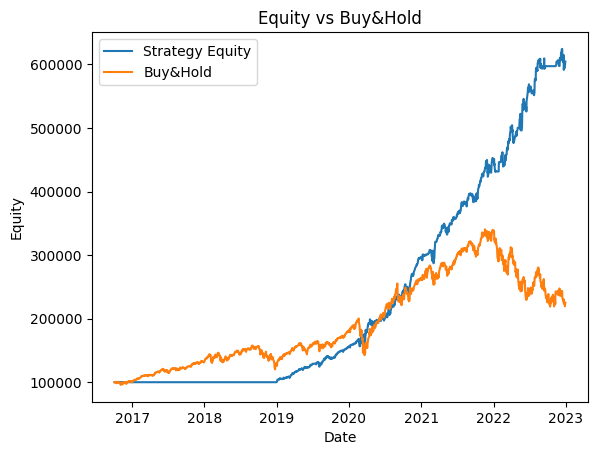

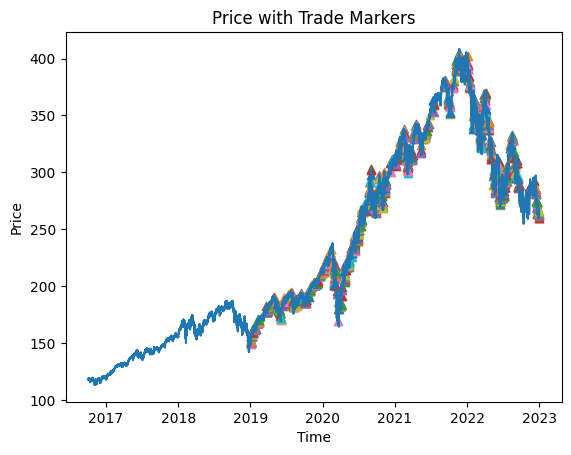

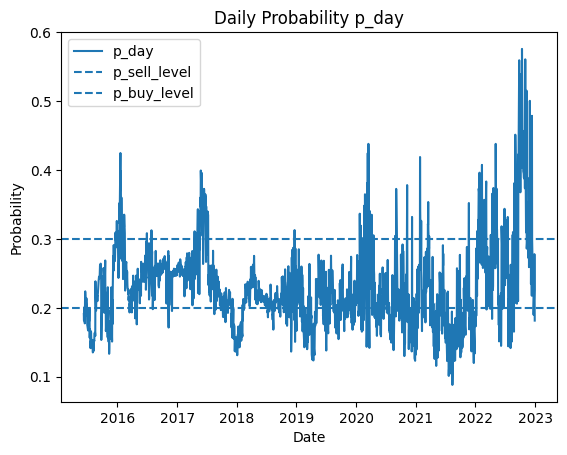

[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2022\trades.csv
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2022\daily_log.csv
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2022\equity_vs_buyhold.png
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2022\price_with_trades.png
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2022\p_day.png
[TRADES] total=1679
[TRADES] first_trade_ts=2019-01-02 04:00:00 (sim_start=2019-01-01 00:00:00)


,side,seen_idx,exec_px,qty,fee,reason,ts,p_day,pred,th,gate,pnl,entry_px,entry_idx
0,buy,91478,150.3700,665.026269,0.0,FORCE_BUY->first acceptable 5m signal,2019-01-02 04:00:00,0.166607,4.254107,-0.50,FORCE_BUY,NaN,NaN,NaN
1,sell,91691,150.9200,665.026269,0.0,5m SELL signal,2019-01-03 05:45:00,0.233027,5.232145,2.50,FREE,365.764448,150.37,91478.0
2,buy,91696,150.6000,666.439339,0.0,5m BUY signal,2019-01-03 06:10:00,0.233027,3.695591,-0.50,FREE,NaN,NaN,NaN
3,sell,91707,151.4800,666.439339,0.0,5m SELL signal,2019-01-03 07:05:00,0.233027,5.669931,2.50,FREE,586.466618,150.60,91696.0
4,buy,91744,150.8300,669.311351,0.0,5m BUY signal,2019-01-03 10:10:00,0.233027,4.087289,-0.50,FREE,NaN,NaN,NaN
5,sell,91754,151.2500,669.311351,0.0,5m SELL signal,2019-01-03 11:00:00,0.233027,2.787308,2.50,FREE,281.110767,150.83,91744.0
6,buy,91804,149.7600,675.970498,0.0,5m BUY signal,2019-01-03 15:10:00,0.233027,6.078876,-0.50,FREE,NaN,NaN,NaN
7,sell,91862,151.6000,675.970498,0.0,5m SELL signal,2019-01-04 04:00:00,0.255494,6.171655,-0.50,FREE,1243.785717,149.76,91804.0
8,buy,91874,152.0700,673.881289,0.0,5m BUY signal,2019-01-04 05:00:00,0.255494,4.627963,-0.50,FREE,NaN,NaN,NaN
9,sell,91884,152.5600,673.881289,0.0,5m SELL signal,2019-01-04 05:50:00,0.255494,6.132437,-0.50,FREE,330.201831,152.07,91874.0


,side,seen_idx,exec_px,qty,fee,reason,ts,p_day,pred,th,gate,pnl,entry_px,entry_idx
1629,sell,275743,284.2000,2102.713659,0.0,FORCE_SELL->first acceptable 5m signal,2022-11-28 05:25:00,0.388841,3.995710,-0.50,FORCE_SELL,-8915.505916,288.4400,275609.0
1630,buy,276544,287.0200,2082.054289,0.0,5m BUY signal,2022-12-02 08:30:00,0.288830,3.585996,1.65,FREE,NaN,NaN,NaN
1631,sell,276625,293.2300,2082.054289,0.0,5m SELL signal,2022-12-02 15:15:00,0.288830,4.543376,2.15,FREE,12929.557134,287.0200,276544.0
1632,buy,276629,292.1290,2089.901308,0.0,5m BUY signal,2022-12-02 15:35:00,0.288830,3.268665,1.65,FREE,NaN,NaN,NaN
1633,sell,276712,292.2300,2089.901308,0.0,FORCE_SELL->first acceptable 5m signal,2022-12-05 06:45:00,0.329027,2.864047,-0.50,FORCE_SELL,211.080032,292.1290,276629.0
1634,buy,277061,281.7000,2168.022219,0.0,5m BUY signal,2022-12-07 04:00:00,0.234596,4.441324,2.45,FREE,NaN,NaN,NaN
1635,sell,277325,283.5300,2168.022219,0.0,5m SELL signal,2022-12-08 10:05:00,0.267495,12.230705,-0.50,FREE,3967.480661,281.7000,277061.0
1636,buy,277339,282.6050,2175.118416,0.0,5m BUY signal,2022-12-08 11:15:00,0.267495,2.910658,-0.50,FREE,NaN,NaN,NaN
1637,sell,277345,283.9000,2175.118416,0.0,5m SELL signal,2022-12-08 11:45:00,0.267495,20.142820,-0.50,FREE,2816.778348,282.6050,277339.0
1638,buy,277669,282.7500,2183.965051,0.0,5m BUY signal,2022-12-12 07:15:00,0.217568,4.014309,-0.50,FREE,NaN,NaN,NaN


,date,equity,cash,pos,buy_th,sell_th
1553,2022-12-02,610251.181854,0.000000,1,1.80,-0.50
1554,2022-12-05,610731.859154,610731.859154,0,2.20,-0.50
1555,2022-12-06,610731.859154,610731.859154,0,2.45,-0.50
1556,2022-12-07,606569.256494,0.000000,1,-0.50,-0.50
1557,2022-12-08,617516.118164,617516.118164,0,-0.50,2.40
1558,2022-12-09,617516.118164,617516.118164,0,-0.50,2.40
1559,2022-12-12,623893.323646,0.000000,1,-0.50,2.45
1560,2022-12-13,624417.585394,624417.585394,0,-0.50,-0.50
1561,2022-12-14,624417.585394,624417.585394,0,-0.50,-0.50
1562,2022-12-15,612597.890579,0.000000,1,-0.50,-0.50


In [ ]:
# ============================================================
# DAILY-ONLY PROB (exact daily logic as provided)
# + 5m Chan/XGB trading engine
# + DAILY GATE that triggers "WAIT FOR FIRST ACCEPTABLE 5m SIGNAL" (NOT immediate)
#
# Key behavior:
# - Daily prob p_day computed exactly with your daily model loop
# - Gate:
#     FORCE_BUY  => day restricted to BUY only; if flat, MUST enter on first acceptable BUY signal
#     FORCE_SELL => day restricted to SELL only; if long, MUST exit on first acceptable SELL signal
#     FREE/NO_P  => normal 5m trading (buy when flat, sell when long)
#
# Outputs:
# - output_dir/trades.csv
# - output_dir/daily_log.csv
# - output_dir/equity_vs_buyhold.png
# - output_dir/price_with_trades.png
# - output_dir/p_day.png
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from dataclasses import dataclass
from typing import Dict, Any, List, Optional, Tuple

import xgboost as xgb
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# Project imports
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime

try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"


# ============================================================
# 0) Shared utilities: CSV load + column pick
# ============================================================
# ============================================================
# NEW: Macro daily features (local CSVs) + base_dir one-hot
# ============================================================

def load_daily_csv_generic(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"CSV must contain open/close columns: {path}")
    if high_col is None: high_col = close_col
    if low_col  is None: low_col  = close_col

    df["_open"]  = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"]  = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"]   = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"]   = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["ts_norm"] = df["timestamp"].dt.normalize()
    return df


def compute_kline_features_generic(df: pd.DataFrame) -> pd.DataFrame:
    # 和你现在 compute_daily_kline_features 本质一致，保留同一套 KLINE_KEYS
    d = df.copy().sort_values("timestamp").reset_index(drop=True)

    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)
    v = d["_vol"].astype(float) if "_vol" in d.columns else pd.Series([0.0]*len(d), index=d.index)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h-l).abs(), (h-prev_c).abs(), (l-prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range"] = (h - l).fillna(0.0)
    d["range_over_atr"] = _safe_div(d["range"], d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)

    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 20, 60]:
        m = v.rolling(w).mean()
        s = v.rolling(w).std()
        d[f"vol_ratio_{w}"] = _safe_div(v, m).replace([np.inf, -np.inf], np.nan).fillna(1.0)
        d[f"vol_z_{w}"] = ((v - m) / (s + 1e-12)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    d["vol_jump"] = _safe_div(v, v.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(1.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t*t).sum()
        return 0.0 if den <= 0 else float((t*x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d


def make_kline_dict_prefixed(row: pd.Series, prefix: str) -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = row[k] if k in row.index else 0.0
        out[f"{prefix}{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


def load_macro_features_from_folder(folder: str, files: Dict[str, str], chan_start: str) -> pd.DataFrame:
    """
    files: dict prefix -> filename, e.g. {"vix_":"VIX.csv"}
    returns: DataFrame with ts_norm + {prefix}{KLINE_KEYS} columns
    """
    out = None
    for pref, fn in files.items():
        path = os.path.join(folder, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Macro file not found: {path}")

        dfm = load_daily_csv_generic(path)
        dfm = dfm[dfm["timestamp"] >= pd.to_datetime(chan_start)].copy().reset_index(drop=True)
        dfm_feat = compute_kline_features_generic(dfm)

        cols = ["ts_norm"] + KLINE_KEYS
        dfm_feat = dfm_feat[cols].copy()
        dfm_feat = dfm_feat.rename(columns={k: f"{pref}{k}" for k in KLINE_KEYS})

        out = dfm_feat.copy() if out is None else out.merge(dfm_feat, on="ts_norm", how="outer")

    if out is None:
        out = pd.DataFrame(columns=["ts_norm"])
    return out.sort_values("ts_norm").reset_index(drop=True)


def _get_underlying_pipeline(model):
    # If calibrated, take first calibrated classifier's estimator (pipeline)
    if hasattr(model, "calibrated_classifiers_") and len(getattr(model, "calibrated_classifiers_", [])) > 0:
        cc0 = model.calibrated_classifiers_[0]
        if hasattr(cc0, "estimator") and cc0.estimator is not None:
            return cc0.estimator
    return model


def feature_importance_from_lr(model, top_n: int = 80) -> pd.DataFrame:
    pipe = _get_underlying_pipeline(model)
    if not (hasattr(pipe, "named_steps") and "vec" in pipe.named_steps and "lr" in pipe.named_steps):
        return pd.DataFrame(columns=["feature", "coef", "abs_coef"])
    vec = pipe.named_steps["vec"]
    lr = pipe.named_steps["lr"]

    try:
        names = np.array(vec.get_feature_names_out(), dtype=object)
    except Exception:
        names = np.array(getattr(vec, "feature_names_", []), dtype=object)

    coef = lr.coef_.ravel()
    if len(names) != len(coef):
        return pd.DataFrame(columns=["feature", "coef", "abs_coef"])

    df_imp = pd.DataFrame({"feature": names, "coef": coef})
    df_imp["abs_coef"] = df_imp["coef"].abs()
    return df_imp.sort_values("abs_coef", ascending=False).head(int(top_n)).reset_index(drop=True)


def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def load_ohlcv_csv(path: str, freq_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"{freq_name} CSV must contain open/close columns.")
    if high_col is None: high_col = close_col
    if low_col  is None: low_col  = close_col

    df["_open"]  = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"]  = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"]   = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"]   = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["day"] = df["timestamp"].dt.normalize()
    return df


# ============================================================
# 1) Chan builders
# ============================================================

def to_ctime(ts) -> CTime:
    if isinstance(ts, CTime):
        return ts
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        pass
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
    except Exception:
        pass
    s = dt.strftime("%Y-%m-%d %H:%M:%S")
    try:
        return CTime(s, auto=False)
    except Exception:
        return CTime(s)

def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW:  float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct, "timestamp": ct, "datetime": ct, "dt": ct,
        "open": float(o), "high": float(h), "low": float(l), "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu

def feed_chan_one(chan_obj, klu: CKLine_Unit):
    if hasattr(chan_obj, "process_new_kline"):
        return chan_obj.process_new_kline(klu)
    if hasattr(chan_obj, "step_load"):
        return chan_obj.step_load([klu])
    raise AttributeError("Chan object has neither process_new_kline nor step_load")


# ============================================================
# 2) DAILY FEATURES (EXACT from your daily model)
# ============================================================

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def compute_daily_kline_features(df_day: pd.DataFrame) -> pd.DataFrame:
    d = df_day.copy().sort_values("timestamp").reset_index(drop=True)
    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)
    v = d["_vol"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h-l).abs(), (h-prev_c).abs(), (l-prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range"] = (h - l).fillna(0.0)
    d["range_over_atr"] = _safe_div(d["range"], d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)
    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 20, 60]:
        m = v.rolling(w).mean()
        s = v.rolling(w).std()
        d[f"vol_ratio_{w}"] = _safe_div(v, m).replace([np.inf, -np.inf], np.nan).fillna(1.0)
        d[f"vol_z_{w}"] = ((v - m) / (s + 1e-12)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    d["vol_jump"] = _safe_div(v, v.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(1.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t*t).sum()
        return 0.0 if den <= 0 else float((t*x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d

KLINE_KEYS = [
    "ret1","ret_5","ret_10","ret_20","ret_40",
    "vol_5","vol_10","vol_20","vol_40",
    "atr_14","range_over_atr","close_pos","gap",
    "vol_ratio_5","vol_ratio_20","vol_ratio_60",
    "vol_z_20","vol_z_60","vol_jump",
    "above_ma_20","above_ma_50","above_ma_100",
    "slope40",
]

def make_kline_dict(row: pd.Series) -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = row[k] if k in row.index else 0.0
        out[f"k_{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# 3) DAILY BSP helpers (EXACT from your daily model)
# ============================================================

def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "timestamp" in rr:
        rr["timestamp"] = pd.to_datetime(rr["timestamp"])
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr

def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []

def latest_bsp_dir_up_to(bsp_rows: List[Dict[str, Any]], ts: pd.Timestamp) -> Optional[str]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= ts]
    if not past:
        return None
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    return str(past[-1].get("direction", "")).lower()

def make_daily_bsp_context(bsp_hist: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_hist if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "ctx_has_bsp": 0.0,
            "ctx_last_dir_buy": 0.0,
            "ctx_last_dir_sell": 0.0,
            "ctx_days_since_last_bsp": 999.0,
            "ctx_days_since_last_buy": 999.0,
            "ctx_days_since_last_sell": 999.0,
            "ctx_density_total": 0.0,
            "ctx_density_buy": 0.0,
            "ctx_density_sell": 0.0,
            "ctx_density_imb": 0.0,
        }
    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    def _days_since(target: str) -> float:
        for r in reversed(past):
            if str(r.get("direction", "")).lower() == target:
                return float((cur_ts.normalize() - pd.to_datetime(r["timestamp"]).normalize()).days)
        return 999.0

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    return {
        "ctx_has_bsp": 1.0,
        "ctx_last_dir_buy": 1.0 if last_dir == "buy" else 0.0,
        "ctx_last_dir_sell": 1.0 if last_dir == "sell" else 0.0,
        "ctx_days_since_last_bsp": days_since_last,
        "ctx_days_since_last_buy": _days_since("buy"),
        "ctx_days_since_last_sell": _days_since("sell"),
        "ctx_density_total": float(len(recent)),
        "ctx_density_buy": float(buy),
        "ctx_density_sell": float(sell),
        "ctx_density_imb": float((sell - buy) / tot),
    }

def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    cur_end_i = 0
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
            cur_end_i = i
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
            cur_dir = d
            cur_end = bsps[i]
            cur_end_i = i
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
    return ends

def regime_for_day_from_ends(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]; b = ends[k+1]
        a_ts, a_dir = a["end_ts"], a["end_dir"]
        b_ts, b_dir = b["end_ts"], b["end_dir"]
        if (day_norm >= a_ts) and (day_norm <= b_ts):
            if a_dir == "buy" and b_dir == "sell":
                return "up"
            if a_dir == "sell" and b_dir == "buy":
                return "down"
    return "unknown"

def label_confirm_extreme(df_day_feat: pd.DataFrame, idx: int, N: int, base_dir: str) -> Optional[int]:
    if N <= 0:
        return None
    if idx + N >= len(df_day_feat):
        return None
    h0 = float(df_day_feat.loc[idx, "_high"])
    l0 = float(df_day_feat.loc[idx, "_low"])
    fut = df_day_feat.loc[idx+1:idx+N]
    if fut.empty:
        return None
    if base_dir == "sell":
        mx = float(fut["_high"].max())
        return 1 if mx < h0 else 0
    if base_dir == "buy":
        mn = float(fut["_low"].min())
        return 1 if mn > l0 else 0
    return None

def make_daily_features(kline_row: pd.Series,
                        bsp_hist_up_to_day: List[Dict[str, Any]],
                        p_val: float,
                        dp_minK: float,
                        dp_maxK: float,
                        regime: str) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats.update(make_kline_dict(kline_row))
    ts = pd.to_datetime(kline_row["timestamp"])
    feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))
    feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
    feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
    feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0
    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0
    return feats

def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1
        ))
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base

def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]

@dataclass
class DailyProbState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


# ============================================================
# 4) Gate logic (daily)
# ============================================================

def gate_from_p(p_day: float, p_sell_level: float, p_buy_level: float) -> str:
    if not np.isfinite(p_day):
        return "NO_P"
    if p_day >= p_sell_level:
        return "FORCE_SELL"
    if p_day <= p_buy_level:
        return "FORCE_BUY"
    return "FREE"


# ============================================================
# 5) 5m model + thresholds (from your old system)
# ============================================================

LABEL_COLS = {"best_return_pct"}
BSP_TYPE_MAP = {"1":1,"2":2,"3a":3,"1p":4,"2s":5,"3b":6}

def prepare_ml_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()

    if "direction" in df.columns:
        d = df["direction"].fillna("unknown").astype(str).str.lower()
        df["direction_encoded"] = np.where(d == "buy", 1, np.where(d == "sell", 0, -1)).astype(np.int32)

    if "bsp_type" in df.columns:
        t = df["bsp_type"].fillna("unknown").astype(str).str.lower()
        df["bsp_type_encoded"] = t.map(BSP_TYPE_MAP).fillna(0).astype(np.int32)

    df = df.replace([np.inf, -np.inf], np.nan)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in LABEL_COLS]

    if numeric_cols:
        imputer = SimpleImputer(strategy="mean")
        imputed = imputer.fit_transform(df[numeric_cols])
        df[numeric_cols] = pd.DataFrame(imputed, columns=numeric_cols, index=df.index).fillna(0.0)

    return df

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    exclude = set(LABEL_COLS) | {
        "timestamp","code","direction","bsp_type","klu_idx",
        "has_best_exit","best_exit_type","best_exit_klu_idx","best_exit_price",
        "regime_bucket",
    }
    num_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cols = [c for c in num_cols if c not in exclude]
    return sorted(cols)

def to_float_matrix(df: pd.DataFrame, cols: List[str]) -> np.ndarray:
    if not cols:
        return np.zeros((len(df), 0), dtype=np.float32)
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X.to_numpy(dtype=np.float32, copy=False)

@dataclass
class RetModelPack:
    feature_cols: List[str]
    model_ret: xgb.XGBRegressor

def _fit_ret_pack(df_dir: pd.DataFrame, feature_cols: List[str], seed: int) -> RetModelPack:
    ret_df = df_dir.dropna(subset=["best_return_pct"]).copy()
    X = to_float_matrix(ret_df, feature_cols)
    y = ret_df["best_return_pct"].to_numpy(dtype=np.float32)

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=4,
    )
    model.fit(X, y)
    return RetModelPack(feature_cols=feature_cols, model_ret=model)

def train_models_two_sided_ret_only(
    bsp_df: pd.DataFrame,
    feature_cols: List[str],
    min_samples_total: int = 300,
) -> Tuple[Optional[RetModelPack], Optional[RetModelPack]]:
    if bsp_df.empty or "direction" not in bsp_df.columns:
        return None, None
    df = bsp_df.copy()
    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    buy_df = df[df["direction"].astype(str).str.lower() == "buy"].copy()
    sell_df = df[df["direction"].astype(str).str.lower() == "sell"].copy()

    buy_pack = None
    if len(buy_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        buy_pack = _fit_ret_pack(buy_df, feature_cols, seed=42)

    sell_pack = None
    if len(sell_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        sell_pack = _fit_ret_pack(sell_df, feature_cols, seed=52)

    return buy_pack, sell_pack

def predict_ret(pack: RetModelPack, row_df: pd.DataFrame) -> float:
    X = to_float_matrix(row_df, pack.feature_cols)
    return float(pack.model_ret.predict(X)[0])

def make_ret_grid(start: float = -0.5, end: float = 2.5, step: float = 0.05) -> List[float]:
    vals = np.arange(start, end + 1e-12, step, dtype=float)
    return [float(x) for x in vals]

def _bars_from_days(days: float, bar_interval_minutes: int) -> int:
    minutes = float(days) * 24.0 * 60.0
    return max(1, int(round(minutes / float(bar_interval_minutes))))

def label_bestlookahead_for_ready_points(
    bsp_rows: List[Dict[str, Any]],
    highs: np.ndarray,
    lows: np.ndarray,
    closes: np.ndarray,
    lookahead_days: float,
    bar_interval_minutes: int,
    current_bar_idx: int,
):
    if not bsp_rows:
        return
    lookahead_bars = _bars_from_days(lookahead_days, bar_interval_minutes)
    n = len(closes)

    for r in bsp_rows:
        if not np.isnan(r.get("best_return_pct", np.nan)):
            continue
        i = r.get("klu_idx", None)
        if i is None:
            continue
        i = int(i)
        end_i = i + lookahead_bars
        if end_i >= n:
            continue
        if end_i > current_bar_idx:
            continue

        d = str(r.get("direction", "buy")).lower()
        c0 = float(closes[i])

        if d == "buy":
            mx = float(np.nanmax(highs[i + 1 : end_i + 1]))
            r["best_return_pct"] = (mx - c0) / c0 * 100.0
        else:
            mn = float(np.nanmin(lows[i + 1 : end_i + 1]))
            r["best_return_pct"] = (c0 - mn) / c0 * 100.0


# ----- threshold selection via realized sim (simple global, not per-bucket to keep it stable) -----

def _simulate_realized_ret_only_long(
    events: List[Dict[str, Any]],
    pred_buy: Dict[Tuple, float],
    pred_sell: Dict[Tuple, float],
    buy_th: float,
    sell_th: float,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    end_bar_idx: int,
    fee_pct: float = 0.0,
) -> Tuple[float, int]:
    cash = 1.0
    pos = 0
    qty = 0.0
    trades = 0

    def exec_next_open(idx: int) -> Optional[float]:
        if not (0 <= idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    for r in events:
        d = str(r.get("direction", "")).lower()
        ki = int(r.get("klu_idx", -1))
        px = exec_next_open(ki)
        if px is None:
            continue

        if pos == 0 and d == "buy":
            key = (int(r.get("klu_idx",-1)), "buy", str(r.get("bsp_type","?")))
            pr = pred_buy.get(key)
            if pr is not None and pr >= float(buy_th):
                notional = cash
                spend = notional * (1 + fee_pct)
                if spend > cash:
                    spend = cash
                    notional = spend / (1 + fee_pct)
                qty = notional / px
                cash -= spend
                pos = 1
                trades += 1

        elif pos == 1 and d == "sell":
            key = (int(r.get("klu_idx",-1)), "sell", str(r.get("bsp_type","?")))
            pr = pred_sell.get(key)
            if pr is not None and pr >= float(sell_th):
                cash += (qty * px) * (1 - fee_pct)
                qty = 0.0
                pos = 0
                trades += 1

    end_px = float(closes[end_bar_idx])
    eq = cash if pos == 0 else (cash + qty * end_px)
    return float(eq), int(trades)

def choose_thresholds_global_realized(
    df_5m: pd.DataFrame,
    bsp_rows: List[Dict[str, Any]],
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    asof_bar_idx: int,
    window_days: float,
    ret_grid: List[float],
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    fee_pct: float = 0.0,
    min_open_signals: int = 10,
) -> Optional[Tuple[float, float]]:
    if df_5m.empty or not bsp_rows or buy_pack is None or sell_pack is None:
        return None

    end_ts = pd.to_datetime(df_5m.loc[asof_bar_idx, "timestamp"])
    start_ts = end_ts - pd.Timedelta(days=float(window_days))

    # events in window
    events = []
    buy_cand = []
    sell_cand = []
    for r in bsp_rows:
        t = pd.to_datetime(r.get("timestamp", None), errors="coerce")
        if pd.isna(t) or not (start_ts <= t <= end_ts):
            continue
        ki = r.get("klu_idx", None)
        if ki is None:
            continue
        rr = dict(r)
        rr["klu_idx"] = int(ki)
        events.append(rr)
        d = str(rr.get("direction","")).lower()
        if d == "buy":
            buy_cand.append(rr)
        elif d == "sell":
            sell_cand.append(rr)

    if len(buy_cand) < int(min_open_signals) or len(sell_cand) < 1:
        return None

    events.sort(key=lambda x: int(x["klu_idx"]))

    # preds maps (keyed by klu_idx)
    buy_df = prepare_ml_dataset(pd.DataFrame(buy_cand))
    for c in buy_pack.feature_cols:
        if c not in buy_df.columns:
            buy_df[c] = 0.0
    buy_pred = buy_pack.model_ret.predict(to_float_matrix(buy_df, buy_pack.feature_cols)).astype(float)
    pred_buy = {(int(buy_cand[i]["klu_idx"]), "buy", str(buy_cand[i].get("bsp_type","?"))): float(buy_pred[i]) for i in range(len(buy_cand))}

    sell_df = prepare_ml_dataset(pd.DataFrame(sell_cand))
    for c in sell_pack.feature_cols:
        if c not in sell_df.columns:
            sell_df[c] = 0.0
    sell_pred = sell_pack.model_ret.predict(to_float_matrix(sell_df, sell_pack.feature_cols)).astype(float)
    pred_sell = {(int(sell_cand[i]["klu_idx"]), "sell", str(sell_cand[i].get("bsp_type","?"))): float(sell_pred[i]) for i in range(len(sell_cand))}

    end_bar_idx = asof_bar_idx
    best_eq = None
    best_pair = None

    for bt in ret_grid:
        for st in ret_grid:
            eq, trades = _simulate_realized_ret_only_long(
                events=events,
                pred_buy=pred_buy,
                pred_sell=pred_sell,
                buy_th=float(bt),
                sell_th=float(st),
                next_open_by_idx=next_open_by_idx,
                closes=closes,
                end_bar_idx=end_bar_idx,
                fee_pct=fee_pct,
            )
            if best_eq is None or eq > best_eq:
                best_eq = float(eq)
                best_pair = (float(bt), float(st))

    return best_pair


# ============================================================
# 6) Execution engine (next_open execution)
# ============================================================

class ExecutionEngine:
    def __init__(self, initial_capital: float, fee_pct: float):
        self.cash = float(initial_capital)
        self.fee_pct = float(fee_pct)
        self.pos = 0
        self.qty = 0.0
        self.entry_px = None
        self.entry_idx = None
        self.pending_order = None
        self.trades = []

    def _exec_px(self, seen_idx: int, next_open_by_idx: np.ndarray) -> Optional[float]:
        if not (0 <= seen_idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[seen_idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    def place_order_for_next_bar(self, side: str, seen_idx: int, reason: str, meta: dict = None, overwrite=True):
        if self.pending_order is not None and not overwrite:
            return
        self.pending_order = {"side": side, "seen_idx": int(seen_idx), "reason": reason, "meta": dict(meta) if meta else {}}

    def maybe_execute_pending(self, next_open_by_idx: np.ndarray):
        if self.pending_order is None:
            return
        side = self.pending_order["side"]
        idx  = self.pending_order["seen_idx"]
        reason = self.pending_order["reason"]
        meta = self.pending_order.get("meta", {}) or {}

        px = self._exec_px(idx, next_open_by_idx)
        if px is None:
            return

        fee = self.fee_pct

        if side == "buy" and self.pos == 0:
            notional = self.cash / (1.0 + fee)
            fee_amt = notional * fee
            qty = notional / px
            self.cash -= (notional + fee_amt)
            self.pos = 1
            self.qty = qty
            self.entry_px = px
            self.entry_idx = idx
            self.trades.append({"side":"buy","seen_idx":idx,"exec_px":px,"qty":qty,"fee":fee_amt,"reason":reason, **meta})

        elif side == "sell" and self.pos == 1:
            notional = self.qty * px
            fee_amt = notional * fee
            recv = notional - fee_amt
            self.cash += recv
            pnl = (px - self.entry_px) * self.qty - fee_amt
            self.trades.append({
                "side":"sell","seen_idx":idx,"exec_px":px,"qty":self.qty,"fee":fee_amt,"reason":reason,
                "pnl": pnl, "entry_px": self.entry_px, "entry_idx": self.entry_idx, **meta
            })
            self.pos = 0
            self.qty = 0.0
            self.entry_px = None
            self.entry_idx = None

        self.pending_order = None

    def mark_to_market(self, last_close: float) -> float:
        px = float(last_close)
        if self.pos == 0:
            return float(self.cash)
        return float(self.cash + self.qty * px)


# ============================================================
# 7) 5m index load (for next_open execution + buy&hold)
# ============================================================

def load_5m_index(df_5m: pd.DataFrame, start_time: str, end_time: str):
    df = df_5m.copy()
    st = pd.to_datetime(start_time)
    et = pd.to_datetime(end_time)
    df = df[(df["timestamp"] >= st) & (df["timestamp"] <= et)].copy().reset_index(drop=True)

    # normalize columns expected by this runner
    df = df.rename(columns={
        "_open":"Open","_high":"High","_low":"Low","_close":"Close","_vol":"Volume"
    })
    df.columns = [str(c).strip() for c in df.columns]

    # 2) if duplicates exist, keep the first occurrence
    if not df.columns.is_unique:
        dupes = df.columns[df.columns.duplicated()].tolist()
        print("[WARN] duplicate columns found:", dupes)
        df = df.loc[:, ~df.columns.duplicated(keep="first")]
    df["date"] = df["timestamp"].dt.date
    df["next_open"] = df["Open"].shift(-1)
    df["next_close"] = df["Close"].shift(-1)

    next_open_by_idx = df["next_open"].to_numpy()
    next_close_by_idx = df["next_close"].to_numpy()
    closes = df["Close"].to_numpy(dtype=float)
    highs  = df["High"].to_numpy(dtype=float)
    lows   = df["Low"].to_numpy(dtype=float)

    day_close_map = df.groupby("date")["Close"].last().to_dict()
    all_days = sorted(df["date"].unique())
    return df, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days

def compute_buy_hold_equity(day_close_map: dict, daily_dates: list, initial_capital: float) -> pd.Series:
    closes, dates = [], []
    for d in daily_dates:
        px = day_close_map.get(d)
        if px is None or pd.isna(px):
            continue
        dates.append(d)
        closes.append(float(px))
    if not closes:
        return pd.Series(dtype=float)
    first = closes[0]
    equity = [initial_capital * (c / first) for c in closes]
    return pd.Series(equity, index=pd.to_datetime(dates))


# ============================================================
# 8) MAIN runner
# ============================================================

def run_daily_prob_then_5m_xgb_gated(
    daily_csv_path: str,
    k5m_csv_path: str,
    code: str = "QQQ",

    daily_chan_start: str = "2016-06-01",
    accumulation_start: str = "2018-10-01",
    sim_start: str = "2019-01-01",
    end_time: str = "2019-12-30",

    # Daily confirm horizon
    N_confirm: int = 5,

    # prob training controls
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    # gate thresholds
    p_sell_level: float = 0.30,
    p_buy_level: float = 0.20,

    # 5m model/training
    bar_interval_minutes: int = 5,
    lookahead_days_5m: float = 2.0,
    retrain_every_days_5m: int = 5,
    min_samples_total_5m: int = 300,

    # threshold optimizer
    threshold_window_days: float = 2.0,
    threshold_ret_grid: Optional[List[float]] = None,
    threshold_min_open_signals: int = 10,

    # portfolio
    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    # Chan buffers
    daily_chan_max_klines: int = 500,
    five_chan_max_klines: int = 20000,

    output_dir: str = "output_dailyprob_gated_5m_xgb",
    verbose: bool = True,
):
    os.makedirs(output_dir, exist_ok=True)

    # ----------------------------
    # Load data
    # ----------------------------
    df_day = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_5m  = load_ohlcv_csv(k5m_csv_path, "5M")

    daily_s = pd.to_datetime(daily_chan_start)
    acc_s   = pd.to_datetime(accumulation_start)
    sim_s   = pd.to_datetime(sim_start)
    end_t   = pd.to_datetime(end_time)

    df_day = df_day[(df_day["timestamp"] >= daily_s) & (df_day["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")
    #df_day_feat = compute_daily_kline_features(df_day)

    df_5m = df_5m[(df_5m["timestamp"] >= acc_s) & (df_5m["timestamp"] <= end_t + pd.Timedelta(days=1))].copy()
    df_5m = df_5m.sort_values("timestamp").reset_index(drop=True)

    # 5m indexed structure
    df_5m_idx, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days = load_5m_index(
        df_5m, accumulation_start, end_time
    )
    buy_hold = compute_buy_hold_equity(day_close_map, all_days, initial_capital)

    # ----------------------------
    # Chan config
    # ----------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    chan_5m = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_5M],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(five_chan_max_klines),
    )

    # =========================================================
    # PHASE 1 (REPLACED): Build daily prob p_by_day
    # ONE MODEL (buy+sell mixed) + MACRO features + base_dir one-hot
    # =========================================================

    # ---- load daily bars and compute features (use same feature set) ----
    df_day = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_day = df_day[(df_day["timestamp"] >= daily_s) & (df_day["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")

    # compute daily features using same KLINE_KEYS set
    df_day_feat = compute_kline_features_generic(df_day)
    df_day_feat["ts_norm"] = df_day_feat["timestamp"].dt.normalize()

    # ---- load macro features from same folder as daily_csv_path ----
    daily_folder = os.path.dirname(os.path.abspath(daily_csv_path))
    macro_files = {
        "vix_":   "VIX.csv",
        "dxy_":   "DXY.csv",
        "us10y_": "US10Y.csv",
        "us30y_": "US30Y.csv",
        "xau_":   "XAU.csv",
        "nyxbt_": "NYXBT.csv",
    }
    macro_feat = load_macro_features_from_folder(daily_folder, macro_files, chan_start=daily_chan_start)
    df_day_feat = df_day_feat.merge(macro_feat, on="ts_norm", how="left").sort_values("timestamp").reset_index(drop=True)

    macro_cols = [c for c in df_day_feat.columns if any(c.startswith(pref) for pref in macro_files.keys())]

    # ---- daily chan + bsp buffers ----
    bsp_rows_daily: List[Dict[str, Any]] = []
    seen_bsp_daily = set()

    # ONE model training buffers
    X_days: List[Dict[str, float]] = []
    y_days: List[int] = []
    st = DailyProbState()
    pending_idx: List[int] = []

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day: Dict[pd.Timestamp, float] = {}

    def make_daily_features_one_model(
        kline_row: pd.Series,
        macro_row: Optional[pd.Series],
        bsp_hist_up_to_day: List[Dict[str, Any]],
        p_val: float,
        dp_minK: float,
        dp_maxK: float,
        regime: str,
        base_dir: Optional[str],
    ) -> Dict[str, float]:
        feats: Dict[str, float] = {}

        # underlying (SPY/QQQ) kline with prefix
        feats.update(make_kline_dict_prefixed(kline_row, prefix="q_"))

        # macro already prefixed columns
        if macro_row is not None:
            for col in macro_row.index:
                val = macro_row[col]
                feats[str(col)] = float(val) if np.isfinite(val) else 0.0

        ts = pd.to_datetime(kline_row["timestamp"])
        feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))

        feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
        feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
        feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0

        rg = str(regime).lower()
        feats["rg_up"] = 1.0 if rg == "up" else 0.0
        feats["rg_down"] = 1.0 if rg == "down" else 0.0
        feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0

        bd = str(base_dir).lower() if base_dir is not None else "none"
        feats["bd_buy"] = 1.0 if bd == "buy" else 0.0
        feats["bd_sell"] = 1.0 if bd == "sell" else 0.0
        feats["bd_none"] = 1.0 if bd not in ("buy", "sell") else 0.0

        return feats

    def maybe_train():
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            try:
                st.model = fit_prob_model_dicts(X_days, y)
                st.trained_n = len(y)
                st.new_labels = 0
                if verbose:
                    print(f"[TRAIN][PROB-ONE] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
            except Exception as e:
                if verbose:
                    print(f"[TRAIN][PROB-ONE] skipped: {e}")

    # ---- walk-forward daily loop ----
    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        # collect BSPs
        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        # regime + base_dir today
        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)
        base_dir_today = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        # predict p_day (if model exists)
        p_val = np.nan
        if st.model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            macro_row = df_day_feat.loc[i, macro_cols] if len(macro_cols) else None
            feat_i = make_daily_features_one_model(
                kline_row=r,
                macro_row=macro_row,
                bsp_hist_up_to_day=bsp_hist,
                p_val=0.0,
                dp_minK=0.0,
                dp_maxK=0.0,
                regime=regime,
                base_dir=base_dir_today,
            )
            p_val = float(predict_prob(st.model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        # dp vs min/max prev K
        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        # finalize labels for older days -> add to dataset
        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir_j = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir_j not in ("buy", "sell"):
                continue

            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir_j)
            if y is None:
                continue

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)

            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]
            macro_row_j = df_day_feat.loc[j, macro_cols] if len(macro_cols) else None

            feat_j = make_daily_features_one_model(
                kline_row=df_day_feat.loc[j],
                macro_row=macro_row_j,
                bsp_hist_up_to_day=bsp_hist_j,
                p_val=float(p_series[j]) if np.isfinite(p_series[j]) else 0.0,
                dp_minK=float(dp_vs_minK_series[j]) if np.isfinite(dp_vs_minK_series[j]) else 0.0,
                dp_maxK=float(dp_vs_maxK_series[j]) if np.isfinite(dp_vs_maxK_series[j]) else 0.0,
                regime=regime_j,
                base_dir=base_dir_j,
            )

            X_days.append(feat_j)
            y_days.append(int(y))
            st.new_labels += 1

        maybe_train()

    if verbose:
        y = np.asarray(y_days, dtype=int) if len(y_days) else np.array([], dtype=int)
        if len(y):
            print(f"[LABELS][PROB-ONE] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
        print(f"[MODEL][PROB-ONE] trained={'yes' if st.model is not None else 'no'} trained_n={st.trained_n}")
        print(f"[BSP][DAILY] total={len(bsp_rows_daily)}")

    # optional: save feature importance
    feat_imp_path = os.path.join(output_dir, "daily_lr_feature_importance.csv")
    if st.model is not None:
        try:
            imp_df = feature_importance_from_lr(st.model, top_n=120)
            imp_df.to_csv(feat_imp_path, index=False)
            if verbose:
                print(f"[SAVED] {feat_imp_path}")
        except Exception as e:
            if verbose:
                print(f"[IMP][PROB-ONE] skipped: {e}")


    # =========================================================
    # PHASE 2/3: 5m accumulation + trading with daily gate
    # =========================================================
    print(f"[PHASE2/3] 5m feed begins at accumulation_start={acc_s.date()}, trading starts at sim_start={sim_s.date()}")

    engine = ExecutionEngine(initial_capital=initial_capital, fee_pct=fee_pct)

    bsp_rows_5m: List[Dict[str, Any]] = []
    seen_keys_5m = set()

    buy_pack: Optional[RetModelPack] = None
    sell_pack: Optional[RetModelPack] = None
    last_train_day: Optional[pd.Timestamp] = None

    # live thresholds (global, re-optimized periodically)
    if threshold_ret_grid is None:
        threshold_ret_grid = make_ret_grid(-0.5, 2.5, 0.05)
    buy_ret_th_live = 0.30
    sell_ret_th_live = 0.30

    # per-day gate state
    current_day: Optional[datetime.date] = None
    day_gate: str = "NO_P"
    must_trade_dir: Optional[str] = None   # "buy"/"sell"/None
    allow_buy: bool = True
    allow_sell: bool = True

    daily_log = []

    def maybe_retrain_5m(day_ts: pd.Timestamp):
        nonlocal buy_pack, sell_pack, last_train_day
        if last_train_day is not None and (day_ts - last_train_day).days < int(retrain_every_days_5m):
            return
        dfb = pd.DataFrame(bsp_rows_5m)
        if dfb.empty:
            return
        dfb2 = prepare_ml_dataset(dfb)
        feat_cols = get_feature_columns(dfb2)
        bp, sp = train_models_two_sided_ret_only(dfb2, feat_cols, min_samples_total=min_samples_total_5m)
        if bp is not None:
            buy_pack = bp
        if sp is not None:
            sell_pack = sp
        if (bp is not None) or (sp is not None):
            last_train_day = day_ts
            if verbose:
                print(f"[TRAIN][5M] asof={day_ts.date()} feats={len(feat_cols)} buy={'YES' if bp else 'NO'} sell={'YES' if sp else 'NO'} rows={len(dfb2)}")

    def maybe_opt_thresholds(asof_bar_idx: int):
        nonlocal buy_ret_th_live, sell_ret_th_live
        if buy_pack is None or sell_pack is None:
            return
        out = choose_thresholds_global_realized(
            df_5m=df_5m_idx,
            bsp_rows=bsp_rows_5m,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            asof_bar_idx=asof_bar_idx,
            window_days=threshold_window_days,
            ret_grid=threshold_ret_grid,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            fee_pct=fee_pct,
            min_open_signals=threshold_min_open_signals,
        )
        if out is not None:
            buy_ret_th_live, sell_ret_th_live = out
            if verbose:
                print(f"[TH-OPT][GLOBAL] asof_bar={asof_bar_idx} buy_th={buy_ret_th_live:.2f} sell_th={sell_ret_th_live:.2f}")

    # iterate 5m bars
    sim_start_ts = pd.to_datetime(sim_start)
    last_day_end_idx = None

    for i in range(len(df_5m_idx)):
        bar_ts = pd.to_datetime(df_5m_idx.loc[i, "timestamp"])
        bar_day = bar_ts.date()
        in_sim = (bar_ts >= sim_start_ts)

        # day boundary
        if current_day is None:
            current_day = bar_day

            # init gate for the day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            # restrictions
            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        if bar_day != current_day:
            prev_day = current_day
            prev_day_ts = pd.to_datetime(prev_day)

            # label ready points (no lookahead beyond current bar index)
            label_bestlookahead_for_ready_points(
                bsp_rows=bsp_rows_5m,
                highs=highs, lows=lows, closes=closes,
                lookahead_days=lookahead_days_5m,
                bar_interval_minutes=bar_interval_minutes,
                current_bar_idx=i,
            )

            # retrain + re-opt thresholds at day boundary using last bar idx of previous day
            maybe_retrain_5m(prev_day_ts)
            if last_day_end_idx is not None:
                maybe_opt_thresholds(last_day_end_idx)

            # log EOD equity for prev day
            day_close = day_close_map.get(prev_day)
            equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
            daily_log.append({"date": prev_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                              "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

            if verbose:
                tag = "SIM" if (pd.to_datetime(prev_day) >= sim_start_ts.normalize()) else "ACCUM"
                print(f"[EOD-{tag}] {prev_day} equity={equity:.2f} cash={engine.cash:.2f} pos={engine.pos} "
                      f"| next_day={bar_day} (thresholds kept/updated)")

            # switch day
            current_day = bar_day

            # re-init gate for NEW day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        # track end index of day for optimization
        last_day_end_idx = i

        # execute pending on every bar
        if in_sim:
            engine.maybe_execute_pending(next_open_by_idx)

        # feed 5m chan
        klu = build_klu(
            df_5m_idx.loc[i, "timestamp"],
            df_5m_idx.loc[i, "Open"], df_5m_idx.loc[i, "High"], df_5m_idx.loc[i, "Low"], df_5m_idx.loc[i, "Close"],
            df_5m_idx.loc[i, "Volume"],
        )
        feed_chan_one(chan_5m, klu)

        new_rows = extract_bsp_rows_from_chan(chan_5m)
        if not new_rows:
            continue

        for r0 in new_rows:
            r = dict(r0)
            r.setdefault("timestamp", str(bar_ts))
            r.setdefault("klu_idx", i)

            if "direction" not in r or r["direction"] is None:
                if r.get("is_buy", None) is not None:
                    r["direction"] = "buy" if bool(r["is_buy"]) else "sell"
                else:
                    r["direction"] = "buy"
            r["direction"] = str(r["direction"]).lower()
            if "bsp_type" in r and r["bsp_type"] is not None:
                r["bsp_type"] = str(r["bsp_type"]).lower()

            r.setdefault("best_return_pct", np.nan)

            k = (int(r.get("klu_idx",-1)), str(r.get("direction")), str(r.get("bsp_type")))
            if k in seen_keys_5m:
                continue
            seen_keys_5m.add(k)
            bsp_rows_5m.append(r)

            # no trades during accumulation
            if not in_sim:
                continue

            d = str(r.get("direction","buy")).lower()
            ki = int(r.get("klu_idx", i))

            # apply gate restrictions
            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue

            # if must_trade_dir is active, only accept that direction (first acceptable signal)
            if must_trade_dir is not None and d != must_trade_dir:
                continue

            # decide acceptance using XGB + threshold
            if d == "buy" and engine.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)

                if pr >= float(buy_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="buy",
                        seen_idx=ki,
                        reason=("FORCE_BUY->first acceptable 5m signal" if day_gate=="FORCE_BUY" else "5m BUY signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(buy_ret_th_live), "gate": day_gate}
                    )
                    # once we schedule the forced direction, clear it so we don't keep forcing
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and engine.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)

                if pr >= float(sell_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="sell",
                        seen_idx=ki,
                        reason=("FORCE_SELL->first acceptable 5m signal" if day_gate=="FORCE_SELL" else "5m SELL signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(sell_ret_th_live), "gate": day_gate}
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    # final EOD log
    if current_day is not None:
        day_close = day_close_map.get(current_day)
        equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
        daily_log.append({"date": current_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                          "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

    trades_df = pd.DataFrame(engine.trades)
    daily_df = pd.DataFrame(daily_log)
    if not daily_df.empty:
        daily_df["date"] = pd.to_datetime(daily_df["date"])
        daily_df = daily_df.sort_values("date").reset_index(drop=True)

    # save
    trades_csv = os.path.join(output_dir, "trades.csv")
    daily_csv = os.path.join(output_dir, "daily_log.csv")
    trades_df.to_csv(trades_csv, index=False)
    daily_df.to_csv(daily_csv, index=False)

    # =========================================================
    # Plots (like old ones)
    # =========================================================

    # 1) equity vs buy&hold
    plt.figure()
    if not daily_df.empty:
        plt.plot(daily_df["date"], daily_df["equity"], label="Strategy Equity")
    if len(buy_hold) > 0:
        plt.plot(buy_hold.index, buy_hold.values, label="Buy&Hold")
    plt.legend()
    plt.title("Equity vs Buy&Hold")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    out_eq = os.path.join(output_dir, "equity_vs_buyhold.png")
    plt.savefig(out_eq, dpi=150, bbox_inches="tight")
    plt.show()

    # 2) price with trade markers
    plt.figure()
    plt.plot(df_5m_idx["timestamp"], df_5m_idx["Close"], label="5m Close")
    if not trades_df.empty:
        # map seen_idx -> timestamp
        for _, tr in trades_df.iterrows():
            idx = int(tr["seen_idx"])
            if 0 <= idx < len(df_5m_idx):
                t = pd.to_datetime(df_5m_idx.loc[idx, "timestamp"])
                px = float(tr["exec_px"])
                if tr["side"] if "side" in tr else tr.get("side","") == "buy":
                    plt.scatter([t], [px], marker="^")
                else:
                    plt.scatter([t], [px], marker="v")
    plt.title("Price with Trade Markers")
    plt.xlabel("Time")
    plt.ylabel("Price")
    out_px = os.path.join(output_dir, "price_with_trades.png")
    plt.savefig(out_px, dpi=150, bbox_inches="tight")
    plt.show()

    # 3) daily prob plot
    # build series aligned to daily dates
    days_sorted = sorted(p_by_day.keys())
    if days_sorted:
        plt.figure()
        xs = pd.to_datetime(days_sorted)
        ys = [p_by_day[d] for d in days_sorted]
        plt.plot(xs, ys, label="p_day")
        plt.axhline(p_sell_level, linestyle="--", label="p_sell_level")
        plt.axhline(p_buy_level, linestyle="--", label="p_buy_level")
        plt.legend()
        plt.title("Daily Probability p_day")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        out_p = os.path.join(output_dir, "p_day.png")
        plt.savefig(out_p, dpi=150, bbox_inches="tight")
        plt.show()

    if verbose:
        print(f"[SAVED] {trades_csv}")
        print(f"[SAVED] {daily_csv}")
        print(f"[SAVED] {out_eq}")
        print(f"[SAVED] {out_px}")
        if days_sorted:
            print(f"[SAVED] {out_p}")
        print(f"[TRADES] total={len(trades_df)}")
        if not trades_df.empty:
            # sanity: no trades before sim_start
            ts0 = pd.to_datetime(df_5m_idx.loc[int(trades_df["seen_idx"].min()), "timestamp"])
            print(f"[TRADES] first_trade_ts={ts0} (sim_start={sim_start_ts})")

    return {
        "trades_df": trades_df,
        "daily_log_df": daily_df,
        "p_by_day": p_by_day,
        "buy_hold": buy_hold,
        "output_dir": output_dir,
    }


# ============================================================
# RUN
# ============================================================

res = run_daily_prob_then_5m_xgb_gated(
    daily_csv_path="DataAPI/data/QQQ_DAY.csv",
    k5m_csv_path="DataAPI/data/QQQ_5M.csv",
    code="QQQ",

    daily_chan_start="2014-06-01",
    accumulation_start="2016-10-01",
    sim_start="2019-01-01",
    end_time="2022-12-31",

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    p_sell_level=0.30,
    p_buy_level=0.20,

    lookahead_days_5m=2.0,
    retrain_every_days_5m=5,
    min_samples_total_5m=300,

    threshold_window_days=2.0,
    threshold_ret_grid=None,              # default grid
    threshold_min_open_signals=10,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,           # match your daily model
    five_chan_max_klines=500,

    output_dir="output_dailyprob_gated_5m_xgb_QQQ_2022",
    verbose=True,
)

display(res["trades_df"].head(50))
display(res["trades_df"].tail(50))
display(res["daily_log_df"].tail(20))


In [ ]:
# ============================================================
# DAILY (Chan BSP-based Prob) + 5m Chan/XGB trading engine
# + DAILY GATE that triggers "WAIT FOR FIRST ACCEPTABLE 5m SIGNAL" (NOT immediate)
#
# Daily part (REPLACED):
# - Builds a DAILY Chan (K_DAY) and extracts DAILY BSP signals
# - Creates a walk-forward probability model p_day using:
#     * daily kline features
#     * daily BSP context features (last dir, days since, density, imbalance)
#     * simple regime from BSP chain endpoints (up/down/unknown)
#     * base_dir (latest BSP direction up to that day)
#     * dp features (p - min/max over lookback)
# - Labels are generated via your "extreme confirmation" rule:
#     base_dir == 'sell': y=1 if max(high next N) < high(t0) else 0
#     base_dir == 'buy' : y=1 if min(low  next N) > low(t0)  else 0
#
# 5m part (UNCHANGED):
# - Accumulate 5m BSP rows, label best_return_pct after lookahead
# - Train XGB regressors for buy/sell predicted best_return_pct
# - Optimize thresholds by realized simulation
# - Execute at next open, gated by daily p_day
#
# Outputs:
# - output_dir/trades.csv
# - output_dir/daily_log.csv
# - output_dir/equity_vs_buyhold.png
# - output_dir/price_with_trades.png
# - output_dir/p_day.png
# - output_dir/daily_lr_feature_importance.csv
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from dataclasses import dataclass
from typing import Dict, Any, List, Optional, Tuple

import xgboost as xgb
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# Project imports
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime

try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"


# ============================================================
# 0) Shared utilities
# ============================================================

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def load_ohlcv_csv(path: str, freq_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"{freq_name} CSV must contain open/close columns.")
    if high_col is None: high_col = close_col
    if low_col  is None: low_col  = close_col

    df["_open"]  = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"]  = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"]   = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"]   = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["day"] = df["timestamp"].dt.normalize()
    return df


# ============================================================
# 1) Chan builders
# ============================================================

def to_ctime(ts) -> CTime:
    if isinstance(ts, CTime):
        return ts
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        pass
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
    except Exception:
        pass
    s = dt.strftime("%Y-%m-%d %H:%M:%S")
    try:
        return CTime(s, auto=False)
    except Exception:
        return CTime(s)

def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW:  float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct, "timestamp": ct, "datetime": ct, "dt": ct,
        "open": float(o), "high": float(h), "low": float(l), "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu

def feed_chan_one(chan_obj, klu: CKLine_Unit):
    if hasattr(chan_obj, "process_new_kline"):
        return chan_obj.process_new_kline(klu)
    if hasattr(chan_obj, "step_load"):
        return chan_obj.step_load([klu])
    raise AttributeError("Chan object has neither process_new_kline nor step_load")


# ============================================================
# 2) DAILY features
# ============================================================

KLINE_KEYS = [
    "ret1","ret_5","ret_10","ret_20","ret_40",
    "vol_5","vol_10","vol_20","vol_40",
    "atr_14","range_over_atr","close_pos","gap",
    "vol_ratio_5","vol_ratio_20","vol_ratio_60",
    "vol_z_20","vol_z_60","vol_jump",
    "above_ma_20","above_ma_50","above_ma_100",
    "slope40",
]

def compute_daily_kline_features(df_day: pd.DataFrame) -> pd.DataFrame:
    d = df_day.copy().sort_values("timestamp").reset_index(drop=True)
    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)
    v = d["_vol"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h-l).abs(), (h-prev_c).abs(), (l-prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range"] = (h - l).fillna(0.0)
    d["range_over_atr"] = _safe_div(d["range"], d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)
    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 20, 60]:
        m = v.rolling(w).mean()
        s = v.rolling(w).std()
        d[f"vol_ratio_{w}"] = _safe_div(v, m).replace([np.inf, -np.inf], np.nan).fillna(1.0)
        d[f"vol_z_{w}"] = ((v - m) / (s + 1e-12)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    d["vol_jump"] = _safe_div(v, v.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(1.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t*t).sum()
        return 0.0 if den <= 0 else float((t*x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d

def make_kline_dict(row: pd.Series) -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = row[k] if k in row.index else 0.0
        out[f"k_{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# 3) DAILY BSP helpers
# ============================================================

def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "timestamp" in rr:
        rr["timestamp"] = pd.to_datetime(rr["timestamp"], errors="coerce")
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr

def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []

def latest_bsp_dir_up_to(bsp_rows: List[Dict[str, Any]], ts: pd.Timestamp) -> Optional[str]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= ts]
    if not past:
        return None
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    return str(past[-1].get("direction", "")).lower()

def make_daily_bsp_context(bsp_hist: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_hist if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "ctx_has_bsp": 0.0,
            "ctx_last_dir_buy": 0.0,
            "ctx_last_dir_sell": 0.0,
            "ctx_days_since_last_bsp": 999.0,
            "ctx_days_since_last_buy": 999.0,
            "ctx_days_since_last_sell": 999.0,
            "ctx_density_total": 0.0,
            "ctx_density_buy": 0.0,
            "ctx_density_sell": 0.0,
            "ctx_density_imb": 0.0,
        }
    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    def _days_since(target: str) -> float:
        for r in reversed(past):
            if str(r.get("direction", "")).lower() == target:
                return float((cur_ts.normalize() - pd.to_datetime(r["timestamp"]).normalize()).days)
        return 999.0

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    return {
        "ctx_has_bsp": 1.0,
        "ctx_last_dir_buy": 1.0 if last_dir == "buy" else 0.0,
        "ctx_last_dir_sell": 1.0 if last_dir == "sell" else 0.0,
        "ctx_days_since_last_bsp": days_since_last,
        "ctx_days_since_last_buy": _days_since("buy"),
        "ctx_days_since_last_sell": _days_since("sell"),
        "ctx_density_total": float(len(recent)),
        "ctx_density_buy": float(buy),
        "ctx_density_sell": float(sell),
        "ctx_density_imb": float((sell - buy) / tot),
    }

def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    cur_end_i = 0
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
            cur_end_i = i
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
            cur_dir = d
            cur_end = bsps[i]
            cur_end_i = i
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
    return ends

def regime_for_day_from_ends(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]; b = ends[k+1]
        a_ts, a_dir = a["end_ts"], a["end_dir"]
        b_ts, b_dir = b["end_ts"], b["end_dir"]
        if (day_norm >= a_ts) and (day_norm <= b_ts):
            if a_dir == "buy" and b_dir == "sell":
                return "up"
            if a_dir == "sell" and b_dir == "buy":
                return "down"
    return "unknown"


# ============================================================
# 4) Daily label + model
# ============================================================

def label_confirm_extreme(df_day_feat: pd.DataFrame, idx: int, N: int, base_dir: str) -> Optional[int]:
    if N <= 0:
        return None
    if idx + N >= len(df_day_feat):
        return None
    h0 = float(df_day_feat.loc[idx, "_high"])
    l0 = float(df_day_feat.loc[idx, "_low"])
    fut = df_day_feat.loc[idx+1:idx+N]
    if fut.empty:
        return None
    if base_dir == "sell":
        mx = float(fut["_high"].max())
        return 1 if mx < h0 else 0
    if base_dir == "buy":
        mn = float(fut["_low"].min())
        return 1 if mn > l0 else 0
    return None

def make_daily_features_one_model(
    kline_row: pd.Series,
    bsp_hist_up_to_day: List[Dict[str, Any]],
    p_val: float,
    dp_minK: float,
    dp_maxK: float,
    regime: str,
    base_dir: Optional[str],
) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats.update(make_kline_dict(kline_row))

    ts = pd.to_datetime(kline_row["timestamp"])
    feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))

    feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
    feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
    feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0

    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0

    bd = str(base_dir).lower() if base_dir is not None else "none"
    feats["bd_buy"] = 1.0 if bd == "buy" else 0.0
    feats["bd_sell"] = 1.0 if bd == "sell" else 0.0
    feats["bd_none"] = 1.0 if bd not in ("buy", "sell") else 0.0

    return feats

def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1
        ))
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base

def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]

def _get_underlying_pipeline(model):
    if hasattr(model, "calibrated_classifiers_") and len(getattr(model, "calibrated_classifiers_", [])) > 0:
        cc0 = model.calibrated_classifiers_[0]
        if hasattr(cc0, "estimator") and cc0.estimator is not None:
            return cc0.estimator
    return model

def feature_importance_from_lr(model, top_n: int = 80) -> pd.DataFrame:
    pipe = _get_underlying_pipeline(model)
    if not (hasattr(pipe, "named_steps") and "vec" in pipe.named_steps and "lr" in pipe.named_steps):
        return pd.DataFrame(columns=["feature", "coef", "abs_coef"])
    vec = pipe.named_steps["vec"]
    lr = pipe.named_steps["lr"]

    try:
        names = np.array(vec.get_feature_names_out(), dtype=object)
    except Exception:
        names = np.array(getattr(vec, "feature_names_", []), dtype=object)

    coef = lr.coef_.ravel()
    if len(names) != len(coef):
        return pd.DataFrame(columns=["feature", "coef", "abs_coef"])

    df_imp = pd.DataFrame({"feature": names, "coef": coef})
    df_imp["abs_coef"] = df_imp["coef"].abs()
    return df_imp.sort_values("abs_coef", ascending=False).head(int(top_n)).reset_index(drop=True)

@dataclass
class DailyProbState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


# ============================================================
# 5) Gate logic (daily)
# ============================================================

def gate_from_p(p_day: float, p_sell_level: float, p_buy_level: float) -> str:
    if not np.isfinite(p_day):
        return "NO_P"
    if p_day >= p_sell_level:
        return "FORCE_SELL"
    if p_day <= p_buy_level:
        return "FORCE_BUY"
    return "FREE"


# ============================================================
# 6) 5m model + thresholds (your old system)
# ============================================================

LABEL_COLS = {"best_return_pct"}
BSP_TYPE_MAP = {"1":1,"2":2,"3a":3,"1p":4,"2s":5,"3b":6}

def prepare_ml_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()

    if "direction" in df.columns:
        d = df["direction"].fillna("unknown").astype(str).str.lower()
        df["direction_encoded"] = np.where(d == "buy", 1, np.where(d == "sell", 0, -1)).astype(np.int32)

    if "bsp_type" in df.columns:
        t = df["bsp_type"].fillna("unknown").astype(str).str.lower()
        df["bsp_type_encoded"] = t.map(BSP_TYPE_MAP).fillna(0).astype(np.int32)

    df = df.replace([np.inf, -np.inf], np.nan)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in LABEL_COLS]

    if numeric_cols:
        imputer = SimpleImputer(strategy="mean")
        imputed = imputer.fit_transform(df[numeric_cols])
        df[numeric_cols] = pd.DataFrame(imputed, columns=numeric_cols, index=df.index).fillna(0.0)

    return df

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    exclude = set(LABEL_COLS) | {
        "timestamp","code","direction","bsp_type","klu_idx",
        "has_best_exit","best_exit_type","best_exit_klu_idx","best_exit_price",
        "regime_bucket",
    }
    num_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cols = [c for c in num_cols if c not in exclude]
    return sorted(cols)

def to_float_matrix(df: pd.DataFrame, cols: List[str]) -> np.ndarray:
    if not cols:
        return np.zeros((len(df), 0), dtype=np.float32)
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X.to_numpy(dtype=np.float32, copy=False)

@dataclass
class RetModelPack:
    feature_cols: List[str]
    model_ret: xgb.XGBRegressor

def _fit_ret_pack(df_dir: pd.DataFrame, feature_cols: List[str], seed: int) -> RetModelPack:
    ret_df = df_dir.dropna(subset=["best_return_pct"]).copy()
    X = to_float_matrix(ret_df, feature_cols)
    y = ret_df["best_return_pct"].to_numpy(dtype=np.float32)

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=4,
    )
    model.fit(X, y)
    return RetModelPack(feature_cols=feature_cols, model_ret=model)

def train_models_two_sided_ret_only(
    bsp_df: pd.DataFrame,
    feature_cols: List[str],
    min_samples_total: int = 300,
) -> Tuple[Optional[RetModelPack], Optional[RetModelPack]]:
    if bsp_df.empty or "direction" not in bsp_df.columns:
        return None, None
    df = bsp_df.copy()
    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    buy_df = df[df["direction"].astype(str).str.lower() == "buy"].copy()
    sell_df = df[df["direction"].astype(str).str.lower() == "sell"].copy()

    buy_pack = None
    if len(buy_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        buy_pack = _fit_ret_pack(buy_df, feature_cols, seed=42)

    sell_pack = None
    if len(sell_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        sell_pack = _fit_ret_pack(sell_df, feature_cols, seed=52)

    return buy_pack, sell_pack

def predict_ret(pack: RetModelPack, row_df: pd.DataFrame) -> float:
    X = to_float_matrix(row_df, pack.feature_cols)
    return float(pack.model_ret.predict(X)[0])

def make_ret_grid(start: float = -0.5, end: float = 2.5, step: float = 0.05) -> List[float]:
    vals = np.arange(start, end + 1e-12, step, dtype=float)
    return [float(x) for x in vals]

def _bars_from_days(days: float, bar_interval_minutes: int) -> int:
    minutes = float(days) * 24.0 * 60.0
    return max(1, int(round(minutes / float(bar_interval_minutes))))

def label_bestlookahead_for_ready_points(
    bsp_rows: List[Dict[str, Any]],
    highs: np.ndarray,
    lows: np.ndarray,
    closes: np.ndarray,
    lookahead_days: float,
    bar_interval_minutes: int,
    current_bar_idx: int,
):
    if not bsp_rows:
        return
    lookahead_bars = _bars_from_days(lookahead_days, bar_interval_minutes)
    n = len(closes)

    for r in bsp_rows:
        if not np.isnan(r.get("best_return_pct", np.nan)):
            continue
        i = r.get("klu_idx", None)
        if i is None:
            continue
        i = int(i)
        end_i = i + lookahead_bars
        if end_i >= n:
            continue
        if end_i > current_bar_idx:
            continue

        d = str(r.get("direction", "buy")).lower()
        c0 = float(closes[i])

        if d == "buy":
            mx = float(np.nanmax(highs[i + 1 : end_i + 1]))
            r["best_return_pct"] = (mx - c0) / c0 * 100.0
        else:
            mn = float(np.nanmin(lows[i + 1 : end_i + 1]))
            r["best_return_pct"] = (c0 - mn) / c0 * 100.0

def _simulate_realized_ret_only_long(
    events: List[Dict[str, Any]],
    pred_buy: Dict[Tuple, float],
    pred_sell: Dict[Tuple, float],
    buy_th: float,
    sell_th: float,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    end_bar_idx: int,
    fee_pct: float = 0.0,
) -> Tuple[float, int]:
    cash = 1.0
    pos = 0
    qty = 0.0
    trades = 0

    def exec_next_open(idx: int) -> Optional[float]:
        if not (0 <= idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    for r in events:
        d = str(r.get("direction", "")).lower()
        ki = int(r.get("klu_idx", -1))
        px = exec_next_open(ki)
        if px is None:
            continue

        if pos == 0 and d == "buy":
            key = (int(r.get("klu_idx",-1)), "buy", str(r.get("bsp_type","?")))
            pr = pred_buy.get(key)
            if pr is not None and pr >= float(buy_th):
                notional = cash
                spend = notional * (1 + fee_pct)
                if spend > cash:
                    spend = cash
                    notional = spend / (1 + fee_pct)
                qty = notional / px
                cash -= spend
                pos = 1
                trades += 1

        elif pos == 1 and d == "sell":
            key = (int(r.get("klu_idx",-1)), "sell", str(r.get("bsp_type","?")))
            pr = pred_sell.get(key)
            if pr is not None and pr >= float(sell_th):
                cash += (qty * px) * (1 - fee_pct)
                qty = 0.0
                pos = 0
                trades += 1

    end_px = float(closes[end_bar_idx])
    eq = cash if pos == 0 else (cash + qty * end_px)
    return float(eq), int(trades)

def choose_thresholds_global_realized(
    df_5m: pd.DataFrame,
    bsp_rows: List[Dict[str, Any]],
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    asof_bar_idx: int,
    window_days: float,
    ret_grid: List[float],
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    fee_pct: float = 0.0,
    min_open_signals: int = 10,
) -> Optional[Tuple[float, float]]:
    if df_5m.empty or not bsp_rows or buy_pack is None or sell_pack is None:
        return None

    end_ts = pd.to_datetime(df_5m.loc[asof_bar_idx, "timestamp"])
    start_ts = end_ts - pd.Timedelta(days=float(window_days))

    events = []
    buy_cand = []
    sell_cand = []
    for r in bsp_rows:
        t = pd.to_datetime(r.get("timestamp", None), errors="coerce")
        if pd.isna(t) or not (start_ts <= t <= end_ts):
            continue
        ki = r.get("klu_idx", None)
        if ki is None:
            continue
        rr = dict(r)
        rr["klu_idx"] = int(ki)
        events.append(rr)
        d = str(rr.get("direction","")).lower()
        if d == "buy":
            buy_cand.append(rr)
        elif d == "sell":
            sell_cand.append(rr)

    if len(buy_cand) < int(min_open_signals) or len(sell_cand) < 1:
        return None

    events.sort(key=lambda x: int(x["klu_idx"]))

    buy_df = prepare_ml_dataset(pd.DataFrame(buy_cand))
    for c in buy_pack.feature_cols:
        if c not in buy_df.columns:
            buy_df[c] = 0.0
    buy_pred = buy_pack.model_ret.predict(to_float_matrix(buy_df, buy_pack.feature_cols)).astype(float)
    pred_buy = {(int(buy_cand[i]["klu_idx"]), "buy", str(buy_cand[i].get("bsp_type","?"))): float(buy_pred[i]) for i in range(len(buy_cand))}

    sell_df = prepare_ml_dataset(pd.DataFrame(sell_cand))
    for c in sell_pack.feature_cols:
        if c not in sell_df.columns:
            sell_df[c] = 0.0
    sell_pred = sell_pack.model_ret.predict(to_float_matrix(sell_df, sell_pack.feature_cols)).astype(float)
    pred_sell = {(int(sell_cand[i]["klu_idx"]), "sell", str(sell_cand[i].get("bsp_type","?"))): float(sell_pred[i]) for i in range(len(sell_cand))}

    end_bar_idx = asof_bar_idx
    best_eq = None
    best_pair = None

    for bt in ret_grid:
        for st in ret_grid:
            eq, trades = _simulate_realized_ret_only_long(
                events=events,
                pred_buy=pred_buy,
                pred_sell=pred_sell,
                buy_th=float(bt),
                sell_th=float(st),
                next_open_by_idx=next_open_by_idx,
                closes=closes,
                end_bar_idx=end_bar_idx,
                fee_pct=fee_pct,
            )
            if best_eq is None or eq > best_eq:
                best_eq = float(eq)
                best_pair = (float(bt), float(st))

    return best_pair


# ============================================================
# 7) Execution engine (next_open execution)
# ============================================================

class ExecutionEngine:
    def __init__(self, initial_capital: float, fee_pct: float):
        self.cash = float(initial_capital)
        self.fee_pct = float(fee_pct)
        self.pos = 0
        self.qty = 0.0
        self.entry_px = None
        self.entry_idx = None
        self.pending_order = None
        self.trades = []

    def _exec_px(self, seen_idx: int, next_open_by_idx: np.ndarray) -> Optional[float]:
        if not (0 <= seen_idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[seen_idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    def place_order_for_next_bar(self, side: str, seen_idx: int, reason: str, meta: dict = None, overwrite=True):
        if self.pending_order is not None and not overwrite:
            return
        self.pending_order = {"side": side, "seen_idx": int(seen_idx), "reason": reason, "meta": dict(meta) if meta else {}}

    def maybe_execute_pending(self, next_open_by_idx: np.ndarray):
        if self.pending_order is None:
            return
        side = self.pending_order["side"]
        idx  = self.pending_order["seen_idx"]
        reason = self.pending_order["reason"]
        meta = self.pending_order.get("meta", {}) or {}

        px = self._exec_px(idx, next_open_by_idx)
        if px is None:
            return

        fee = self.fee_pct

        if side == "buy" and self.pos == 0:
            notional = self.cash / (1.0 + fee)
            fee_amt = notional * fee
            qty = notional / px
            self.cash -= (notional + fee_amt)
            self.pos = 1
            self.qty = qty
            self.entry_px = px
            self.entry_idx = idx
            self.trades.append({"side":"buy","seen_idx":idx,"exec_px":px,"qty":qty,"fee":fee_amt,"reason":reason, **meta})

        elif side == "sell" and self.pos == 1:
            notional = self.qty * px
            fee_amt = notional * fee
            recv = notional - fee_amt
            self.cash += recv
            pnl = (px - self.entry_px) * self.qty - fee_amt
            self.trades.append({
                "side":"sell","seen_idx":idx,"exec_px":px,"qty":self.qty,"fee":fee_amt,"reason":reason,
                "pnl": pnl, "entry_px": self.entry_px, "entry_idx": self.entry_idx, **meta
            })
            self.pos = 0
            self.qty = 0.0
            self.entry_px = None
            self.entry_idx = None

        self.pending_order = None

    def mark_to_market(self, last_close: float) -> float:
        px = float(last_close)
        if self.pos == 0:
            return float(self.cash)
        return float(self.cash + self.qty * px)


# ============================================================
# 8) 5m index load
# ============================================================

def load_5m_index(df_5m: pd.DataFrame, start_time: str, end_time: str):
    df = df_5m.copy()
    st = pd.to_datetime(start_time)
    et = pd.to_datetime(end_time)
    df = df[(df["timestamp"] >= st) & (df["timestamp"] <= et)].copy().reset_index(drop=True)

    df = df.rename(columns={"_open":"Open","_high":"High","_low":"Low","_close":"Close","_vol":"Volume"})
    df.columns = [str(c).strip() for c in df.columns]

    if not df.columns.is_unique:
        df = df.loc[:, ~df.columns.duplicated(keep="first")]

    df["date"] = df["timestamp"].dt.date
    df["next_open"] = df["Open"].shift(-1)
    df["next_close"] = df["Close"].shift(-1)

    next_open_by_idx = df["next_open"].to_numpy()
    next_close_by_idx = df["next_close"].to_numpy()
    closes = df["Close"].to_numpy(dtype=float)
    highs  = df["High"].to_numpy(dtype=float)
    lows   = df["Low"].to_numpy(dtype=float)

    day_close_map = df.groupby("date")["Close"].last().to_dict()
    all_days = sorted(df["date"].unique())
    return df, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days

def compute_buy_hold_equity(day_close_map: dict, daily_dates: list, initial_capital: float) -> pd.Series:
    closes, dates = [], []
    for d in daily_dates:
        px = day_close_map.get(d)
        if px is None or pd.isna(px):
            continue
        dates.append(d)
        closes.append(float(px))
    if not closes:
        return pd.Series(dtype=float)
    first = closes[0]
    equity = [initial_capital * (c / first) for c in closes]
    return pd.Series(equity, index=pd.to_datetime(dates))


# ============================================================
# 9) MAIN runner
# ============================================================

def run_daily_prob_then_5m_xgb_gated(
    daily_csv_path: str,
    k5m_csv_path: str,
    code: str = "QQQ",

    daily_chan_start: str = "2016-06-01",
    accumulation_start: str = "2018-10-01",
    sim_start: str = "2019-01-01",
    end_time: str = "2019-12-30",

    # Daily confirm horizon
    N_confirm: int = 5,

    # prob training controls
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    # gate thresholds
    p_sell_level: float = 0.30,
    p_buy_level: float = 0.20,

    # 5m model/training
    bar_interval_minutes: int = 5,
    lookahead_days_5m: float = 2.0,
    retrain_every_days_5m: int = 5,
    min_samples_total_5m: int = 300,

    # threshold optimizer
    threshold_window_days: float = 2.0,
    threshold_ret_grid: Optional[List[float]] = None,
    threshold_min_open_signals: int = 10,

    # portfolio
    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    # Chan buffers
    daily_chan_max_klines: int = 500,
    five_chan_max_klines: int = 20000,

    output_dir: str = "output_dailyprob_gated_5m_xgb",
    verbose: bool = True,
):
    os.makedirs(output_dir, exist_ok=True)

    # ----------------------------
    # Load data
    # ----------------------------
    df_day_raw = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_5m_raw  = load_ohlcv_csv(k5m_csv_path, "5M")

    daily_s = pd.to_datetime(daily_chan_start)
    acc_s   = pd.to_datetime(accumulation_start)
    sim_s   = pd.to_datetime(sim_start)
    end_t   = pd.to_datetime(end_time)

    df_day = df_day_raw[(df_day_raw["timestamp"] >= daily_s) & (df_day_raw["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")
    df_day_feat = compute_daily_kline_features(df_day)

    df_5m = df_5m_raw[(df_5m_raw["timestamp"] >= acc_s) & (df_5m_raw["timestamp"] <= end_t + pd.Timedelta(days=1))].copy()
    df_5m = df_5m.sort_values("timestamp").reset_index(drop=True)

    df_5m_idx, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days = load_5m_index(
        df_5m, accumulation_start, end_time
    )
    buy_hold = compute_buy_hold_equity(day_close_map, all_days, initial_capital)

    # ----------------------------
    # Chan config
    # ----------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    chan_5m = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_5M],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(five_chan_max_klines),
    )

    # =========================================================
    # PHASE 1: DAILY Chan BSP-based probability p_by_day (REPLACED)
    # =========================================================

    bsp_rows_daily: List[Dict[str, Any]] = []
    seen_bsp_daily = set()

    X_days: List[Dict[str, float]] = []
    y_days: List[int] = []
    st = DailyProbState()
    pending_idx: List[int] = []

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day: Dict[pd.Timestamp, float] = {}

    def maybe_train():
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            try:
                st.model = fit_prob_model_dicts(X_days, y)
                st.trained_n = len(y)
                st.new_labels = 0
                if verbose:
                    print(f"[TRAIN][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
            except Exception as e:
                if verbose:
                    print(f"[TRAIN][DAILY-PROB] skipped: {e}")

    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)
        base_dir_today = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        # predict p_day if model exists
        p_val = np.nan
        if st.model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            feat_i = make_daily_features_one_model(
                kline_row=r,
                bsp_hist_up_to_day=bsp_hist,
                p_val=0.0,
                dp_minK=0.0,
                dp_maxK=0.0,
                regime=regime,
                base_dir=base_dir_today,
            )
            p_val = float(predict_prob(st.model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        # dp vs min/max prev K
        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        # finalize labels for older days
        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir_j = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir_j not in ("buy", "sell"):
                continue

            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir_j)
            if y is None:
                continue

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)

            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]
            feat_j = make_daily_features_one_model(
                kline_row=df_day_feat.loc[j],
                bsp_hist_up_to_day=bsp_hist_j,
                p_val=float(p_series[j]) if np.isfinite(p_series[j]) else 0.0,
                dp_minK=float(dp_vs_minK_series[j]) if np.isfinite(dp_vs_minK_series[j]) else 0.0,
                dp_maxK=float(dp_vs_maxK_series[j]) if np.isfinite(dp_vs_maxK_series[j]) else 0.0,
                regime=regime_j,
                base_dir=base_dir_j,
            )

            X_days.append(feat_j)
            y_days.append(int(y))
            st.new_labels += 1

        maybe_train()

    if verbose:
        y = np.asarray(y_days, dtype=int) if len(y_days) else np.array([], dtype=int)
        if len(y):
            print(f"[LABELS][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
        print(f"[MODEL][DAILY-PROB] trained={'yes' if st.model is not None else 'no'} trained_n={st.trained_n}")
        print(f"[BSP][DAILY] total={len(bsp_rows_daily)}")

    feat_imp_path = os.path.join(output_dir, "daily_lr_feature_importance.csv")
    if st.model is not None:
        try:
            imp_df = feature_importance_from_lr(st.model, top_n=120)
            imp_df.to_csv(feat_imp_path, index=False)
            if verbose:
                print(f"[SAVED] {feat_imp_path}")
        except Exception as e:
            if verbose:
                print(f"[IMP][DAILY-PROB] skipped: {e}")

    # =========================================================
    # PHASE 2/3: 5m accumulation + trading with daily gate
    # =========================================================
    print(f"[PHASE2/3] 5m feed begins at accumulation_start={acc_s.date()}, trading starts at sim_s={sim_s.date()}")

    engine = ExecutionEngine(initial_capital=initial_capital, fee_pct=fee_pct)

    bsp_rows_5m: List[Dict[str, Any]] = []
    seen_keys_5m = set()

    buy_pack: Optional[RetModelPack] = None
    sell_pack: Optional[RetModelPack] = None
    last_train_day: Optional[pd.Timestamp] = None

    if threshold_ret_grid is None:
        threshold_ret_grid = make_ret_grid(-0.5, 2.5, 0.05)
    buy_ret_th_live = 0.30
    sell_ret_th_live = 0.30

    current_day: Optional[datetime.date] = None
    day_gate: str = "NO_P"
    must_trade_dir: Optional[str] = None
    allow_buy: bool = True
    allow_sell: bool = True

    daily_log = []

    def maybe_retrain_5m(day_ts: pd.Timestamp):
        nonlocal buy_pack, sell_pack, last_train_day
        if last_train_day is not None and (day_ts - last_train_day).days < int(retrain_every_days_5m):
            return
        dfb = pd.DataFrame(bsp_rows_5m)
        if dfb.empty:
            return
        dfb2 = prepare_ml_dataset(dfb)
        feat_cols = get_feature_columns(dfb2)
        bp, sp = train_models_two_sided_ret_only(dfb2, feat_cols, min_samples_total=min_samples_total_5m)
        if bp is not None:
            buy_pack = bp
        if sp is not None:
            sell_pack = sp
        if (bp is not None) or (sp is not None):
            last_train_day = day_ts
            if verbose:
                print(f"[TRAIN][5M] asof={day_ts.date()} feats={len(feat_cols)} buy={'YES' if bp else 'NO'} sell={'YES' if sp else 'NO'} rows={len(dfb2)}")

    def maybe_opt_thresholds(asof_bar_idx: int):
        nonlocal buy_ret_th_live, sell_ret_th_live
        if buy_pack is None or sell_pack is None:
            return
        out = choose_thresholds_global_realized(
            df_5m=df_5m_idx,
            bsp_rows=bsp_rows_5m,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            asof_bar_idx=asof_bar_idx,
            window_days=threshold_window_days,
            ret_grid=threshold_ret_grid,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            fee_pct=fee_pct,
            min_open_signals=threshold_min_open_signals,
        )
        if out is not None:
            buy_ret_th_live, sell_ret_th_live = out
            if verbose:
                print(f"[TH-OPT][GLOBAL] asof_bar={asof_bar_idx} buy_th={buy_ret_th_live:.2f} sell_th={sell_ret_th_live:.2f}")

    sim_start_ts = pd.to_datetime(sim_start)
    last_day_end_idx = None

    for i in range(len(df_5m_idx)):
        bar_ts = pd.to_datetime(df_5m_idx.loc[i, "timestamp"])
        bar_day = bar_ts.date()
        in_sim = (bar_ts >= sim_start_ts)

        if current_day is None:
            current_day = bar_day

            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        if bar_day != current_day:
            prev_day = current_day
            prev_day_ts = pd.to_datetime(prev_day)

            label_bestlookahead_for_ready_points(
                bsp_rows=bsp_rows_5m,
                highs=highs, lows=lows, closes=closes,
                lookahead_days=lookahead_days_5m,
                bar_interval_minutes=bar_interval_minutes,
                current_bar_idx=i,
            )

            maybe_retrain_5m(prev_day_ts)
            if last_day_end_idx is not None:
                maybe_opt_thresholds(last_day_end_idx)

            day_close = day_close_map.get(prev_day)
            equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
            daily_log.append({"date": prev_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                              "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

            if verbose:
                tag = "SIM" if (pd.to_datetime(prev_day) >= sim_start_ts.normalize()) else "ACCUM"
                print(f"[EOD-{tag}] {prev_day} equity={equity:.2f} cash={engine.cash:.2f} pos={engine.pos} "
                      f"| next_day={bar_day} (thresholds kept/updated)")

            current_day = bar_day

            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        last_day_end_idx = i

        if in_sim:
            engine.maybe_execute_pending(next_open_by_idx)

        klu = build_klu(
            df_5m_idx.loc[i, "timestamp"],
            df_5m_idx.loc[i, "Open"], df_5m_idx.loc[i, "High"], df_5m_idx.loc[i, "Low"], df_5m_idx.loc[i, "Close"],
            df_5m_idx.loc[i, "Volume"],
        )
        feed_chan_one(chan_5m, klu)

        new_rows = extract_bsp_rows_from_chan(chan_5m)
        if not new_rows:
            continue

        for r0 in new_rows:
            r = dict(r0)
            r.setdefault("timestamp", str(bar_ts))
            r.setdefault("klu_idx", i)

            if "direction" not in r or r["direction"] is None:
                if r.get("is_buy", None) is not None:
                    r["direction"] = "buy" if bool(r["is_buy"]) else "sell"
                else:
                    r["direction"] = "buy"
            r["direction"] = str(r["direction"]).lower()
            if "bsp_type" in r and r["bsp_type"] is not None:
                r["bsp_type"] = str(r["bsp_type"]).lower()

            r.setdefault("best_return_pct", np.nan)

            k = (int(r.get("klu_idx",-1)), str(r.get("direction")), str(r.get("bsp_type")))
            if k in seen_keys_5m:
                continue
            seen_keys_5m.add(k)
            bsp_rows_5m.append(r)

            if not in_sim:
                continue

            d = str(r.get("direction","buy")).lower()
            ki = int(r.get("klu_idx", i))

            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue

            if must_trade_dir is not None and d != must_trade_dir:
                continue

            if d == "buy" and engine.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)

                if pr >= float(buy_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="buy",
                        seen_idx=ki,
                        reason=("FORCE_BUY->first acceptable 5m signal" if day_gate=="FORCE_BUY" else "5m BUY signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(buy_ret_th_live), "gate": day_gate}
                    )
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and engine.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)

                if pr >= float(sell_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="sell",
                        seen_idx=ki,
                        reason=("FORCE_SELL->first acceptable 5m signal" if day_gate=="FORCE_SELL" else "5m SELL signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(sell_ret_th_live), "gate": day_gate}
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    if current_day is not None:
        day_close = day_close_map.get(current_day)
        equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
        daily_log.append({"date": current_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                          "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

    trades_df = pd.DataFrame(engine.trades)
    daily_df = pd.DataFrame(daily_log)
    if not daily_df.empty:
        daily_df["date"] = pd.to_datetime(daily_df["date"])
        daily_df = daily_df.sort_values("date").reset_index(drop=True)

    trades_csv = os.path.join(output_dir, "trades.csv")
    daily_csv = os.path.join(output_dir, "daily_log.csv")
    trades_df.to_csv(trades_csv, index=False)
    daily_df.to_csv(daily_csv, index=False)

    # Plots
    out_eq = os.path.join(output_dir, "equity_vs_buyhold.png")
    out_px = os.path.join(output_dir, "price_with_trades.png")
    out_p  = os.path.join(output_dir, "p_day.png")

    plt.figure()
    if not daily_df.empty:
        plt.plot(daily_df["date"], daily_df["equity"], label="Strategy Equity")
    if len(buy_hold) > 0:
        plt.plot(buy_hold.index, buy_hold.values, label="Buy&Hold")
    plt.legend()
    plt.title("Equity vs Buy&Hold")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.savefig(out_eq, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure()
    plt.plot(df_5m_idx["timestamp"], df_5m_idx["Close"], label="5m Close")
    if not trades_df.empty:
        for _, tr in trades_df.iterrows():
            idx = int(tr["seen_idx"])
            if 0 <= idx < len(df_5m_idx):
                t = pd.to_datetime(df_5m_idx.loc[idx, "timestamp"])
                px = float(tr["exec_px"])
                if tr.get("side","") == "buy":
                    plt.scatter([t], [px], marker="^")
                else:
                    plt.scatter([t], [px], marker="v")
    plt.title("Price with Trade Markers")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.savefig(out_px, dpi=150, bbox_inches="tight")
    plt.show()

    days_sorted = sorted(p_by_day.keys())
    if days_sorted:
        plt.figure()
        xs = pd.to_datetime(days_sorted)
        ys = [p_by_day[d] for d in days_sorted]
        plt.plot(xs, ys, label="p_day")
        plt.axhline(p_sell_level, linestyle="--", label="p_sell_level")
        plt.axhline(p_buy_level, linestyle="--", label="p_buy_level")
        plt.legend()
        plt.title("Daily Probability p_day")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        plt.savefig(out_p, dpi=150, bbox_inches="tight")
        plt.show()

    if verbose:
        print(f"[SAVED] {trades_csv}")
        print(f"[SAVED] {daily_csv}")
        print(f"[SAVED] {out_eq}")
        print(f"[SAVED] {out_px}")
        if days_sorted:
            print(f"[SAVED] {out_p}")
        if st.model is not None:
            print(f"[SAVED] {feat_imp_path}")
        print(f"[TRADES] total={len(trades_df)}")
        if not trades_df.empty:
            ts0 = pd.to_datetime(df_5m_idx.loc[int(trades_df["seen_idx"].min()), "timestamp"])
            print(f"[TRADES] first_trade_ts={ts0} (sim_start={sim_start_ts})")

    return {
        "trades_df": trades_df,
        "daily_log_df": daily_df,
        "p_by_day": p_by_day,
        "buy_hold": buy_hold,
        "output_dir": output_dir,
    }


# ============================================================
# RUN
# ============================================================

res = run_daily_prob_then_5m_xgb_gated(
    daily_csv_path="DataAPI/data/QQQ_DAY.csv",
    k5m_csv_path="DataAPI/data/QQQ_5M.csv",
    code="QQQ",

    daily_chan_start="2014-06-01",
    accumulation_start="2016-10-01",
    sim_start="2019-01-01",
    end_time="2022-12-31",

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    p_sell_level=0.30,
    p_buy_level=0.20,

    lookahead_days_5m=2.0,
    retrain_every_days_5m=5,
    min_samples_total_5m=300,

    threshold_window_days=2.0,
    threshold_ret_grid=None,
    threshold_min_open_signals=10,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,
    five_chan_max_klines=500,

    output_dir="output_dailyprob_gated_5m_xgb_QQQ_2022",
    verbose=True,
)

display(res["trades_df"].head(50))
display(res["trades_df"].tail(50))
display(res["daily_log_df"].tail(20))


[TRAIN][DAILY-PROB] n=200 pos=42 (21.00%)
[TRAIN][DAILY-PROB] n=225 pos=49 (21.78%)
[TRAIN][DAILY-PROB] n=250 pos=59 (23.60%)
[TRAIN][DAILY-PROB] n=275 pos=68 (24.73%)
[TRAIN][DAILY-PROB] n=300 pos=77 (25.67%)
[TRAIN][DAILY-PROB] n=325 pos=82 (25.23%)
[TRAIN][DAILY-PROB] n=350 pos=92 (26.29%)
[TRAIN][DAILY-PROB] n=375 pos=96 (25.60%)
[TRAIN][DAILY-PROB] n=400 pos=107 (26.75%)
[TRAIN][DAILY-PROB] n=425 pos=111 (26.12%)
[TRAIN][DAILY-PROB] n=450 pos=118 (26.22%)
[TRAIN][DAILY-PROB] n=475 pos=122 (25.68%)
[TRAIN][DAILY-PROB] n=500 pos=125 (25.00%)
[TRAIN][DAILY-PROB] n=525 pos=131 (24.95%)
[TRAIN][DAILY-PROB] n=550 pos=138 (25.09%)
[TRAIN][DAILY-PROB] n=575 pos=144 (25.04%)
[TRAIN][DAILY-PROB] n=600 pos=149 (24.83%)
[TRAIN][DAILY-PROB] n=625 pos=150 (24.00%)
[TRAIN][DAILY-PROB] n=650 pos=152 (23.38%)
[TRAIN][DAILY-PROB] n=675 pos=155 (22.96%)
[TRAIN][DAILY-PROB] n=700 pos=156 (22.29%)
[TRAIN][DAILY-PROB] n=725 pos=162 (22.34%)
[TRAIN][DAILY-PROB] n=750 pos=163 (21.73%)
[TRAIN][DAILY-PROB]